In [2]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\mahta\OneDrive - Georgia Institute of Technology\Documents\GitHub\Bank\SDS-CP038-banktermpredict\.venv\Scripts\python.exe
3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


**BankTermPredict Project :
** This dataset collected by a Portugese banking instutition and the goal is that to predict whether a client will subscribe to a term deposit or not
Purpose : this is a supervised learning project and the goal is to predict if the client will subscribe (yes/no) to term deposit (variable ).

Data Dictionary


Part 1 - Data Preprocessing 
Importing the dataset 

Import all alibreries that are needed in this project 

In [3]:
# Import All Libraries Used in this Notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix, 
    classification_report
)
import joblib, json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import iqr
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [4]:
dataset_path = Path("data") / "bank-full.csv"

if not dataset_path.exists():
    raise FileNotFoundError(f"{dataset_path} not found. Check the file name and folder.")

df = pd.read_csv(dataset_path, sep=";")
df.head(30)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [5]:
# Number of rows and colums thorough shape 
print("Shape of the dataset: ")
df.shape

Shape of the dataset: 


(45211, 17)

In [6]:
print ('Info of the dataset: ')
df.info()

Info of the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB



##### Manage missing value, duplicates


In [7]:
# 1.verify NA/Nan value 
missing_value = df.isnull().sum()
print("Missing values in each column: ")
print(missing_value)

Missing values in each column: 
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [8]:
#2. Verify unstructured missing values (e.g., '?', 'NA', 'NaN',empty strings, placeholders)
print("Unstructured missing values in each column: ")
for col in df.columns:
    print(f"{col}: {df[col].isin(["", "NA", "N/A", "null", "NULL", "na", "n/a", "Null", "None", "none"]).sum()}")

Unstructured missing values in each column: 
age: 0
job: 0
marital: 0
education: 0
default: 0
balance: 0
housing: 0
loan: 0
contact: 0
day: 0
month: 0
duration: 0
campaign: 0
pdays: 0
previous: 0
poutcome: 0
y: 0


In [9]:
#3 verify duplicates rows
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicated_rows}")

if duplicated_rows > 0:
    df = df.drop_duplicates()
    print("Duplicate rows have been removed.")

Number of duplicate rows: 0


In [10]:
#4  check for sentinel-coded text placeholders
placeholders = {"unknown", "?", "na", "n/a", "none", "null", "-"}
for col in df.columns:
    if df[col].isin(placeholders).any():
        print(f"Sentinel-coded text placeholders found in column '{col}': {df[col].isin(placeholders).sum()}")

Sentinel-coded text placeholders found in column 'job': 288
Sentinel-coded text placeholders found in column 'education': 1857
Sentinel-coded text placeholders found in column 'contact': 13020
Sentinel-coded text placeholders found in column 'poutcome': 36959


##### EDA : feature distributions 

Histograms: Numeric Features

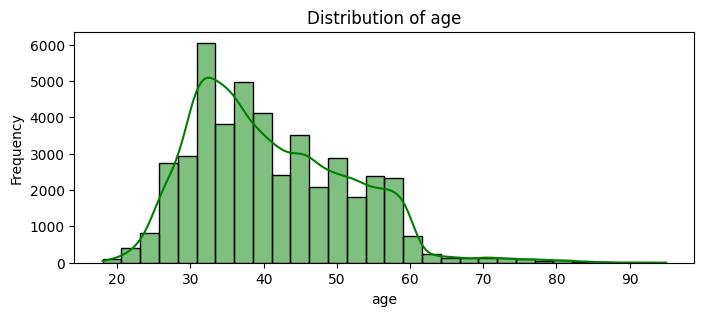

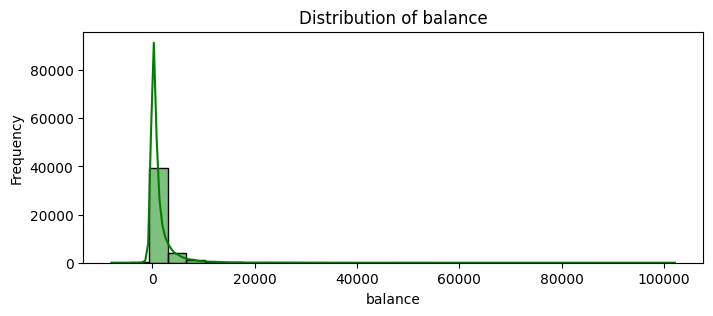

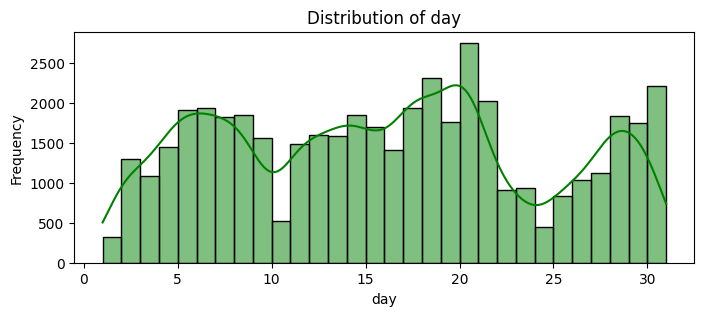

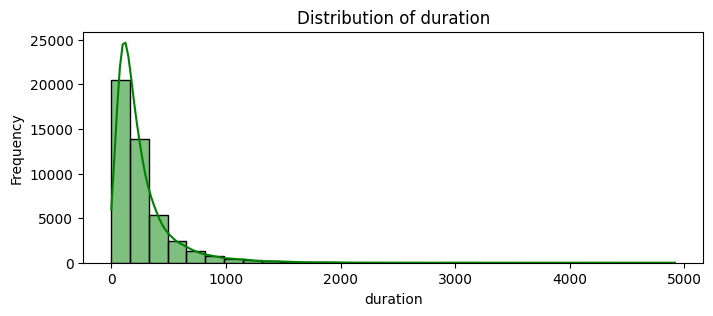

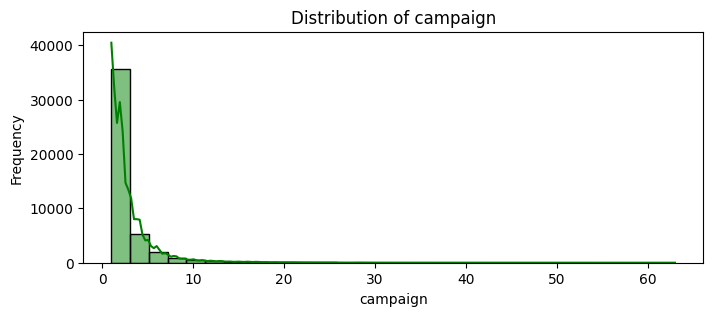

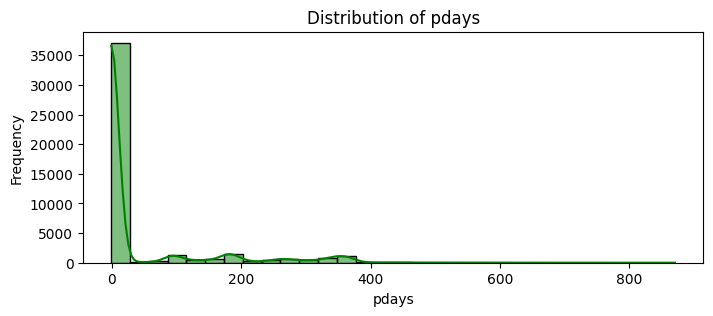

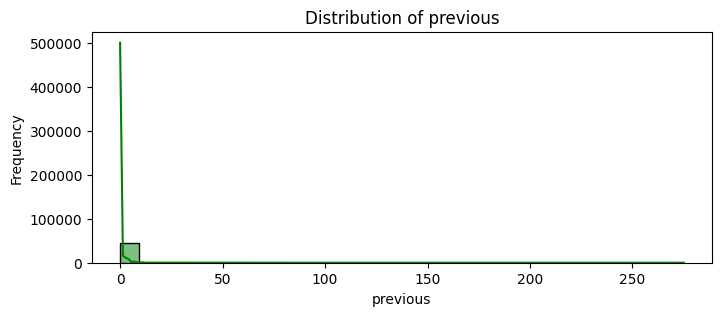

In [11]:
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.histplot(df[col].dropna(),bins=30, kde=True, color='green') 
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show() 


##### Interpretation of histograms:
- age:
  - customers range in age from 18 to 95 years, with a mean age of approximately 41 years
  - It can be seen that age is righ-skewed,centered in the 30s-40s, with fewer older customers(60+), which creates the long right tail

- balance:(average yearly balance in Eur)
  - Highly right- skewed, with most clients near zero and a long positive tail. 
  - This data also includes negative balances, which likey showa customers who are overdrawn in debt

- campaign( number of cantacts in this campaign):
  - Right-skewed , most clients were contavted only 1-3 times,and the frequency drops quickly as the number of contacts increases.
  - It would be useful for feature engineering grouping high vs. low contact counts

- duration:(last contact duration, in seconds):
  - highly right-skewed, most calls are short, and a small number are very long.
  - There are clear outliers (very long calls). These are rare but stretch the scale.

- pdays: number of days since the client was last contacted from a previous campaign.
  - About 81 % of customers had pdays = -1 meaning they were never contacted before.
  - And among the minority who were contacted before, only ~2.28% were contacted again within 30 days

- previous: number of contacts performed before this campaign and for this client 
** -  pdays vs previous:
   - The cross-tab shows a perfect relationship between these two variables.
   - For all 36,954 clients with pdays = -1, we also have previous = 0, meaning they had no prior contact before the current campaign. 
   - For all 8,257 clients with pdays ≠ -1, we have previous > 0, meaning they were contacted before in a previous campaign.
   - There are no mismatches (0 cases where one indicates prior contact and the other does not), so these features are redundant and capture the same information about prior contact.
   - In modeling, keeping both may add duplicate information; it can be reasonable to keep one (often pdays) and drop the other (previous).
   
   

In [12]:
pd.crosstab(df["pdays"].eq(-1), df["previous"].eq(0))


previous,False,True
pdays,,
False,8257,0
True,0,36954


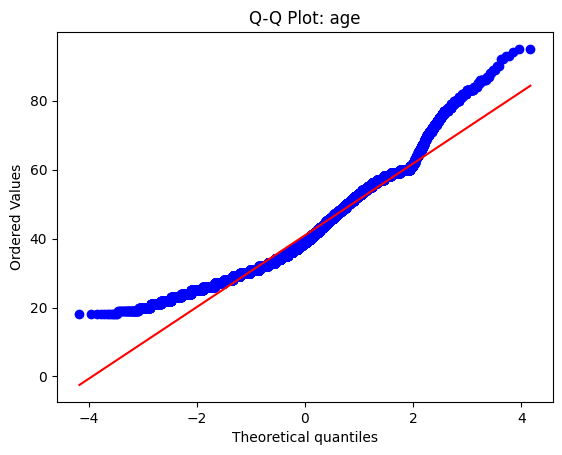

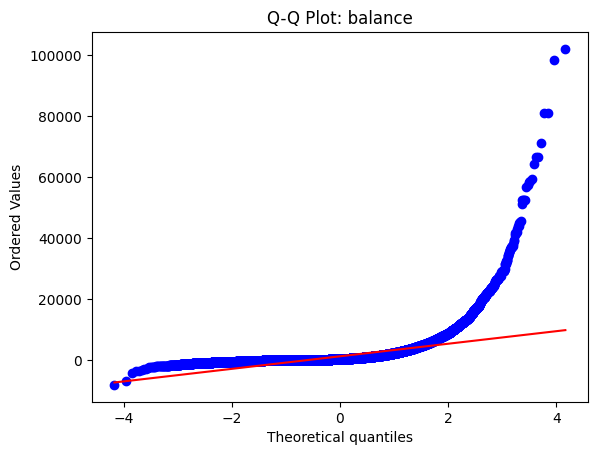

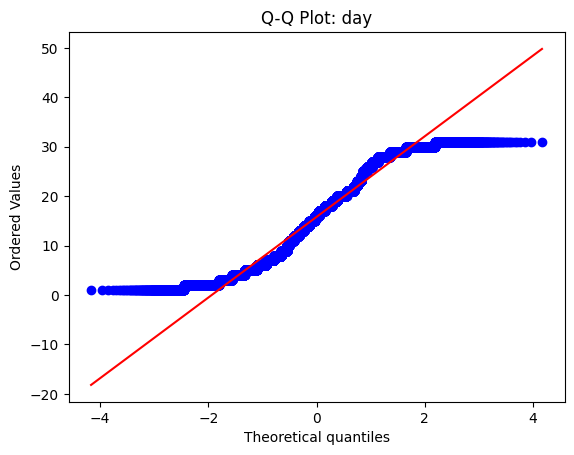

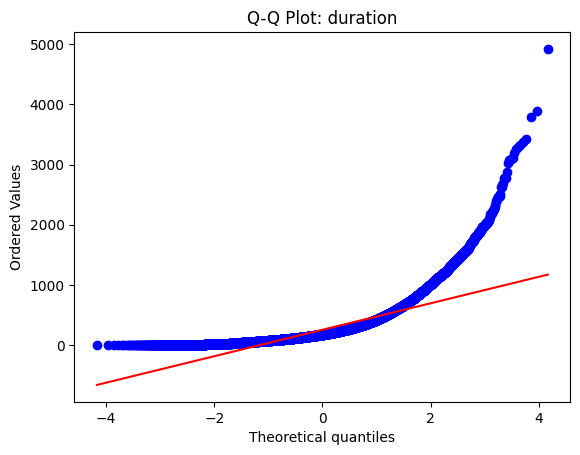

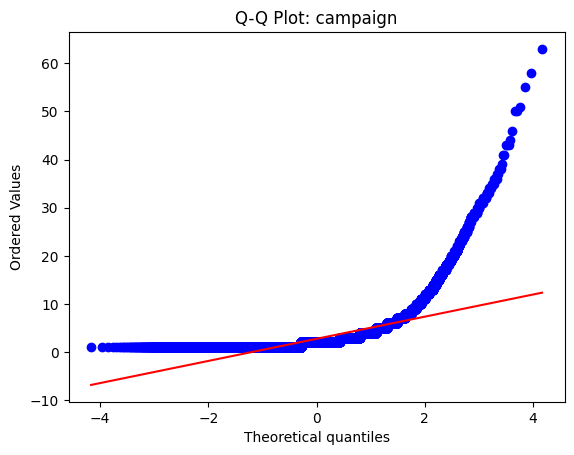

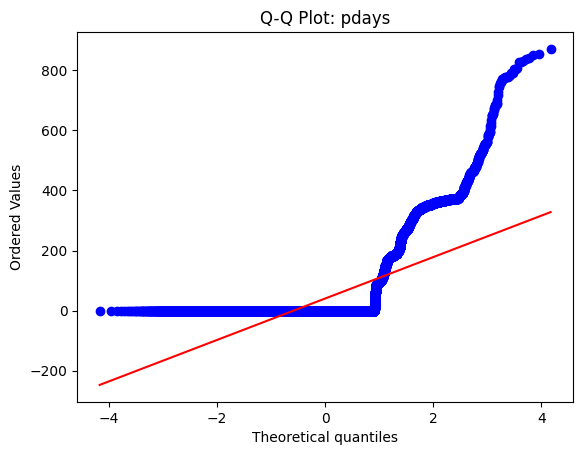

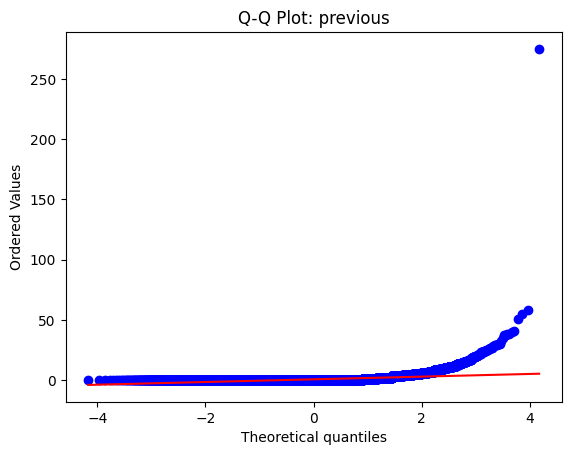

In [13]:
from scipy import stats
for col in num_cols:
    x = df[col].dropna()
    plt.figure()
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {col}")
    plt.show()

---

##### Boxplots: Numeric Features by dependent variable  (y)
Thorough these plot we can discover how each numeric feature differs between clients who subscribed (yes) and those who didn't(no). 


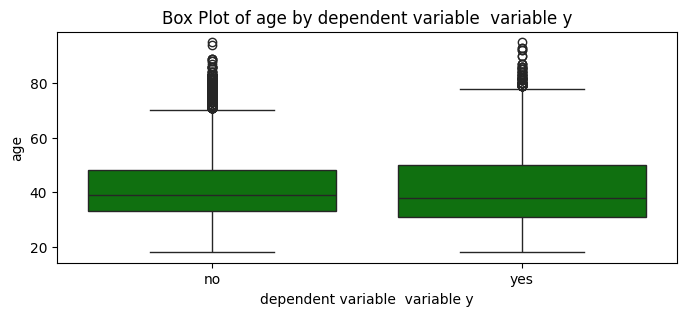

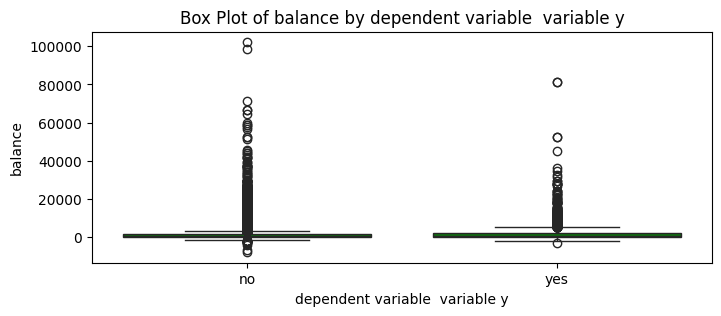

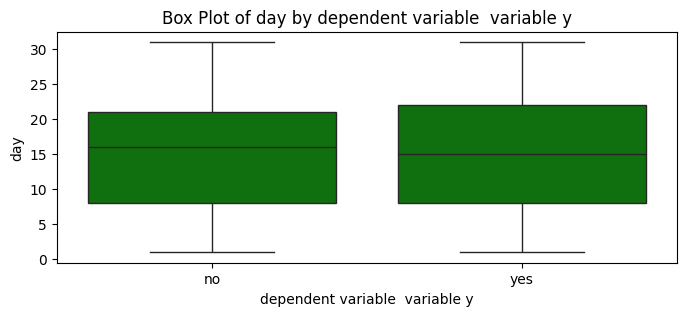

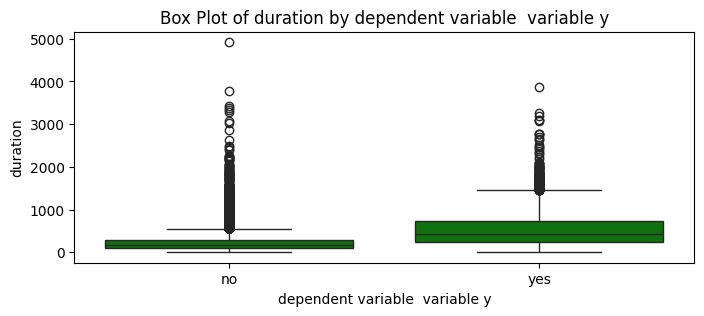

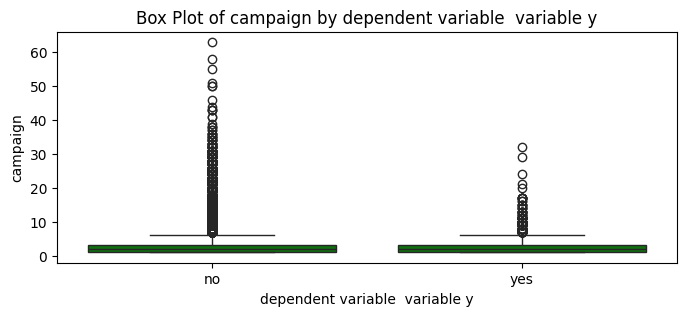

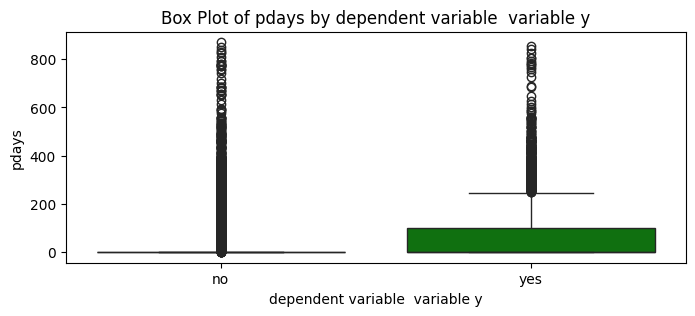

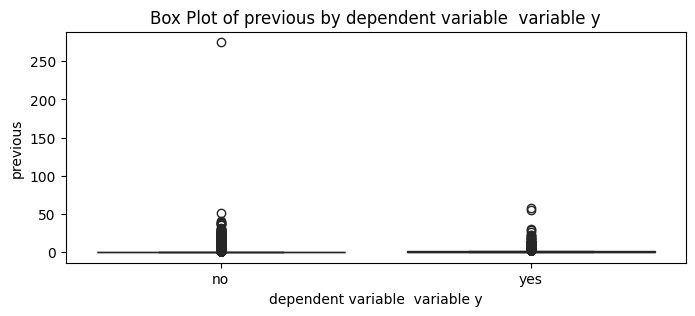

In [14]:
numerical_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
for col in numerical_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x= 'y', y= col  ,data=df, color='green') 
    plt.title(f'Box Plot of {col} by dependent variable  variable y')
    plt.xlabel('dependent variable  variable y')
    plt.ylabel(col)
    plt.show()

##### Interpretation: Boxplots by y

- age:
  - The median age for clients who subscribed (y = yes) is slightly higher than for those who did not (y = no), but the difference is small overall.
  - The yes group shows a wider spread in ages, suggesting subscribers come from a broader age range.
  - Both groups have several older outliers (70s–90s), meaning a small number of very old clients appear in both outcomes.

- balance:
  -  The no group appears to have a wider spread and more extreme outliers than the yes group, although the typical (median) balances are quite similar.
 


- day :
  - The medians are very similar (around the middle of the month), and the spreads overlap a lot, so there is no strong difference between the two groups.
  - There are no clear outliers, and overall the “day” feature does not appear to strongly separate subscribers from non-subscribers.

- duration:
  -  The median duration is clearly higher for the “yes” group, meaning successful subscriptions are generally associated with longer calls.

  -  Both groups have many high-duration outliers, but overall the “yes” distribution is shifted upward.
  -  duration is a leaky feature because it is only known after the call. I exclude it to avoid unrealistically high model performance.

- campaign
  - The typical number of contacts is low in both groups (median around 2), so most clients were reached only a few times regardless of outcome.
  - The “no” group shows many more extreme outliers (very high contact counts), suggesting repeated calls often do not lead to subscription and may reflect   hard-to-convert clients.
  

- pdays
  - pdays is dominated by the special value -1 (never contacted before), especially in the no group.

  -  The yes group has more observations with pdays > -1, suggesting subscribers are more likely to have been contacted in a previous campaign.

- previous
  - There is heavy overlap in previous between subscribers and non-subscribers, since both groups are mostly at 0 and have similar typical ranges.

Refrences: 

  1.1010data. Bank Marketing Data Set. 1010data Documentation.
  
     https://docs.1010data.com/Tutorials/MachineLearningExamples/BankMarketingDataSet_2.html?utm_source=chatgpt.com

---

In [15]:
#Summary statistics for numerical columns
num_cols = df.select_dtypes(include=["number"]).columns
agg_map = {col: ["median", "mean", iqr] for col in num_cols}
summary = df.groupby("y").agg(agg_map).round(2)
summary.columns = [f"{col}_{stat}" for col, stat in summary.columns]

def stat(summary, stat: str):
    cols = [c for c in summary.columns if c.endswith(f"_{stat}")]
    out = summary[cols].copy()
    out.columns = [c.rsplit("_", 1)[0] for c in out.columns]   # drop _median suffix etc.
    return out

median_tbl = stat(summary, "median").reindex(["no","yes"])
mean_tbl   = stat(summary, "mean").reindex(["no","yes"])
iqr_tbl    = stat(summary, "iqr").reindex(["no","yes"])

print("Summary statistics for numerical columns:")

print(f'Medians:\n{median_tbl}')
print(f'Means:\n{mean_tbl}')
print(f'IQRs:\n{iqr_tbl}')

Summary statistics for numerical columns:
Medians:
      age  balance   day  duration  campaign  pdays  previous
y                                                            
no   39.0    417.0  16.0     164.0       2.0   -1.0       0.0
yes  38.0    733.0  15.0     426.0       2.0   -1.0       0.0
Means:
       age  balance    day  duration  campaign  pdays  previous
y                                                              
no   40.84  1303.71  15.89    221.18      2.85  36.42      0.50
yes  41.67  1804.27  15.16    537.29      2.14  68.70      1.17
IQRs:
      age  balance   day  duration  campaign  pdays  previous
y                                                            
no   15.0   1287.0  13.0     184.0       2.0    0.0       0.0
yes  19.0   1949.0  14.0     481.0       2.0   99.0       1.0


##### Summary statistics for numerical columns by dependent variable  (y)    

**Age**
  - Median: no = 39, yes = 38 very similar. 
  - Mean : slightly higher for yes. 
  - IQR = for subscribers are wider (19 vs 15)- subscribers have a slightly wider age spread.

**Balance**
-  Median: subscribers tend to have higher typical balances ( 733 vs 417).
  - Mean : supports higher balances for “yes” (skewed data), (1804 vs 1304).
  - IQR : balances vary more among subscribers (1949 vs 1287).


**Day**
-  Median: almost identical (16 vs 15).
  - Mean : small difference (15.16 vs 15.89).
  - IQR :similar spread ( 14 vs 13).

  **Duration**(leaky)
-  Median: much longer calls for subscribers(426 vs 164).
- Mean : subscribers are about two times higher (537 vs 221).
- IQR : subscribers are about two times higher  (481 vs 184).


**Campaign**
- Median: both 2 - typical contacts are similar.
- Mean : non-subscribers tend to get contacted more (2.85 vs 2.14).
- IQR : both 2 - most clients are within a narrow contact range.

**pdays**
- Media : both -1 - most clients were not previously contacted.
- Mean : among those with history, yes tends to have larger pdays (68.70 vs 36.42). 
- IQR : no = 0 (dominated by -1) vs yes = 99.

**Previous**
- Median: both 0, most clients had 0 prior contacts.
- Mean : subscribers slightly more likely to have prior contacts (1.17 vs 0.50).
   IQR : more variation for yes ; many zeros in no.
  
  
  
  

---


##### Countplots : Categorical Features by dependent variable (y)

These plots dispalys how each categorical variables breaks down by subscribed (yes)vs. not subscribed (no).

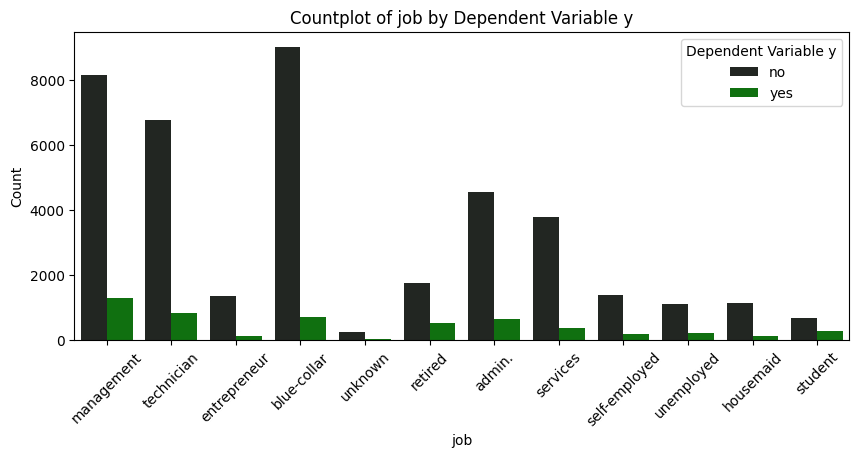

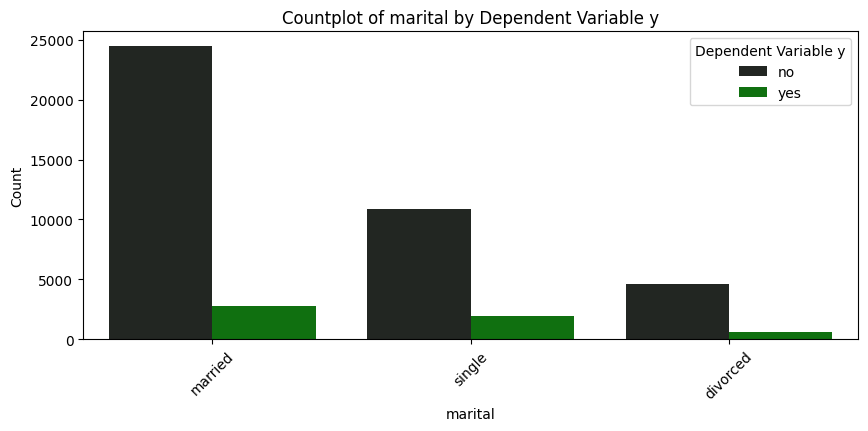

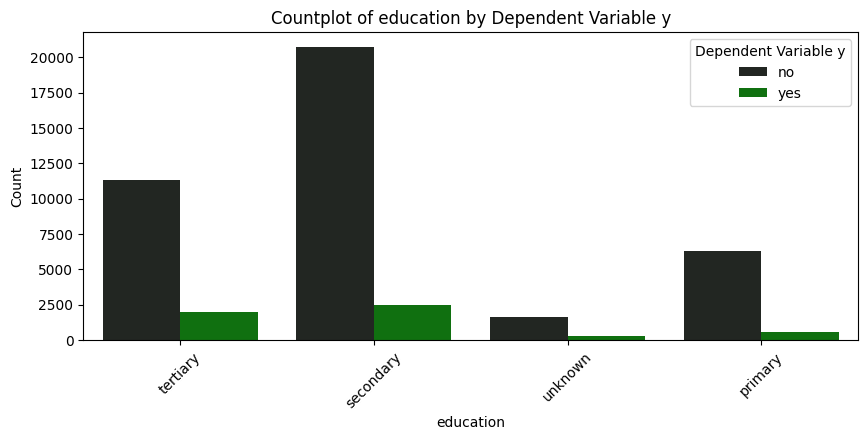

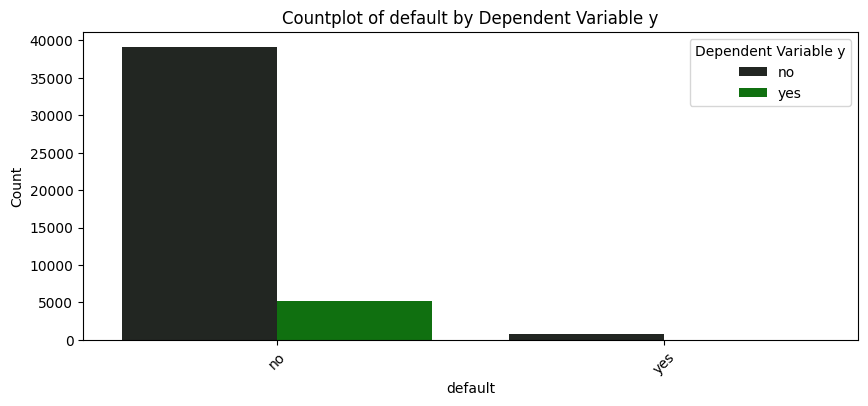

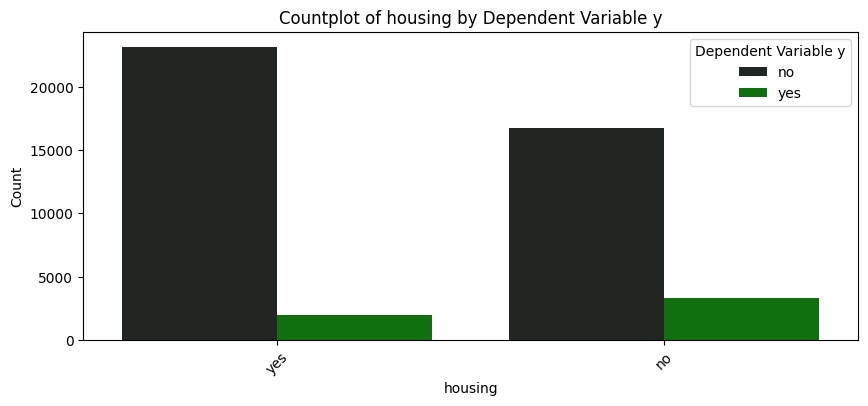

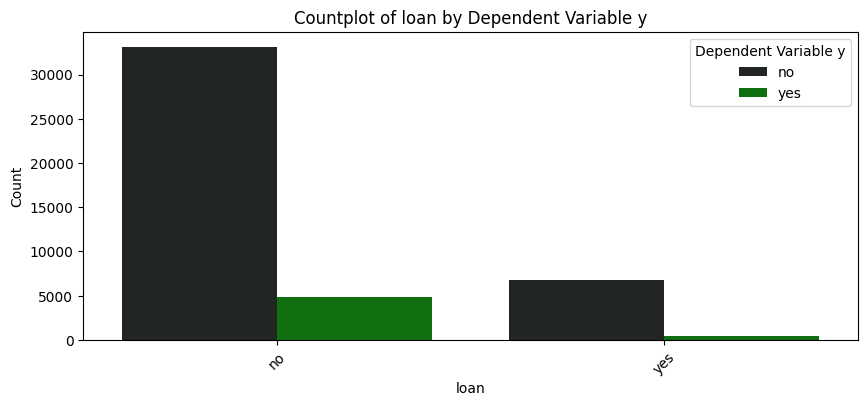

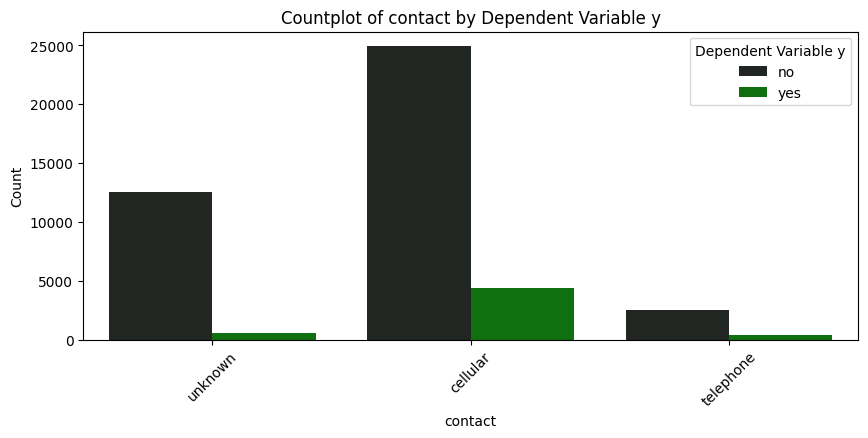

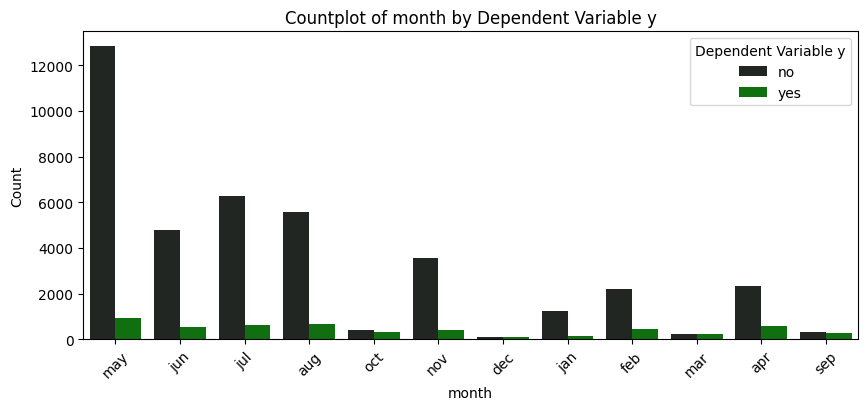

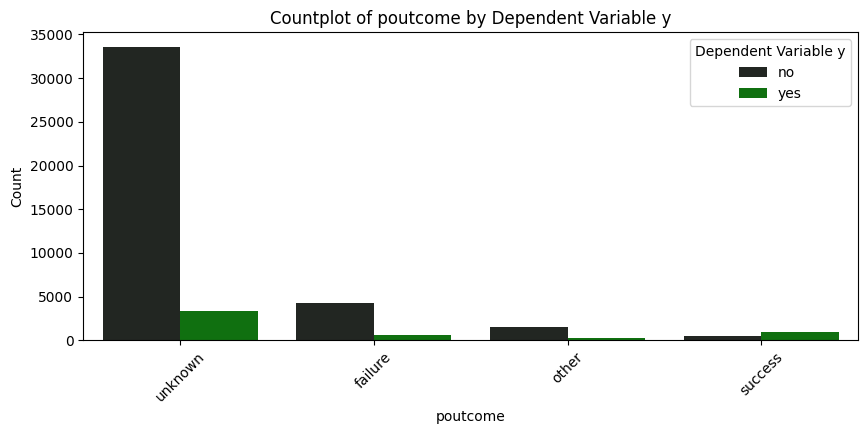

In [16]:
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, hue='y', data=df, color='green')
    plt.title(f"Countplot of {col} by Dependent Variable y")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title='Dependent Variable y')
    plt.show()  


##### Quick Overlook
- Job: Management, technician, entrepreneur, and blue-collar are the largest job categories, and in each of these groups the ‘no’ count is much higher than ‘yes’. The retired group appears to have a more balanced split between ‘yes’ and ‘no’ compared to most other jobs.  

- Martial: Married clients have the highest number of subscribers in total (because they are the largest group). However, the single group shows a higher yes-to-no ratio, meaning “yes” is relatively more common among singles than among married or divorced clients.

- Education: Secondary education shows the highest number of subscribers.

- Default: Most clients are labeled default = no, meaning they are not in credit default. default = yes is extremely rare, so this feature is highly imbalanced and may have limited signal by itself.

- Housing: Clients without housing loans show a slightly higher tendency to subscribe.
 
- Loan : Most clients are in the no personal-loan group, so most ‘no’ outcomes come from that group.

- Contact: Cellular is the most common contact method and also has the highest number of ‘yes’ outcomes. Telephone and unknown have fewer subscriptions overall, and the unknown category is dominated by ‘no’.

- Month: Most calls (and most ‘no’ outcomes) happen in May–August, especially May; other months have much lower volumes, with fewer subscriptions as well.

- Poutcome: Most records have poutcome = unknown. When the previous campaign outcome was success, the share of ‘yes’ is noticeably higher than for failure or other

---


##### Handling "unknown" categories :

Several categorical features include "unknown" as a valid value (e.g., job, education, contact, poutcome). Rather than dropping these rows or guessing the missing value, I will keep "unknown" as its own category.

Why this approach:

- Keeps the full dataset (no loss of clients/records).

- Avoids making assumptions about why the value is missing.

- Allows the model to learn whether "unknown" itself is informative for predicting subscription.

- If later analysis shows "unknown" is not useful, it can be merged with another group or removed.

##### Example: One-hot encoding with “unknown”

During preprocessing, categorical variables will be converted using one-hot encoding, which creates a separate column for each category. For example, if education includes primary, secondary, tertiary, and unknown, one-hot encoding creates:

education_primary, education_secondary, education_tertiary, education_unknown

Each row will have a 1 in the column that matches its category, so “unknown” is treated like any other valid label. If needed later, the education_unknown column can be dropped without changing the rest of the pipeline.

---


##### Stacked (side-by-side) counts - categorical x y

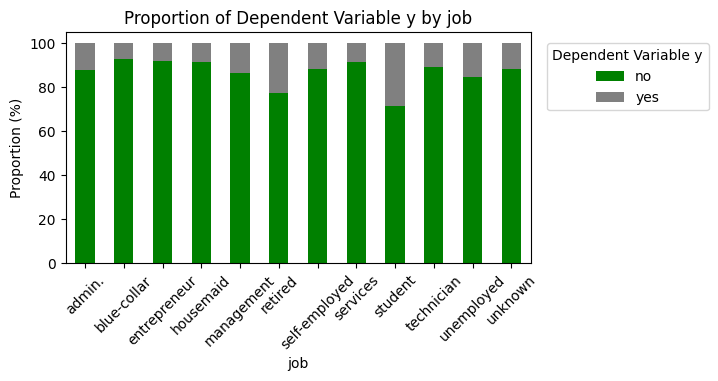

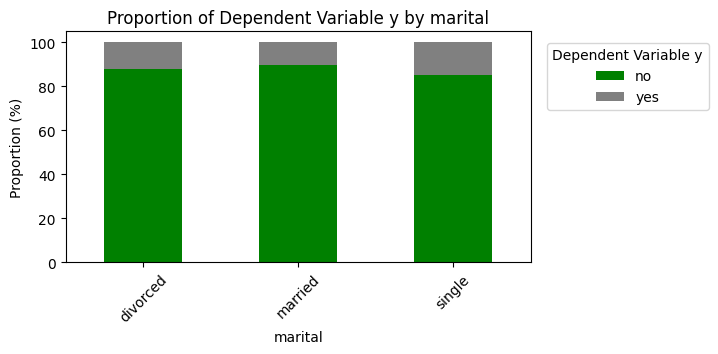

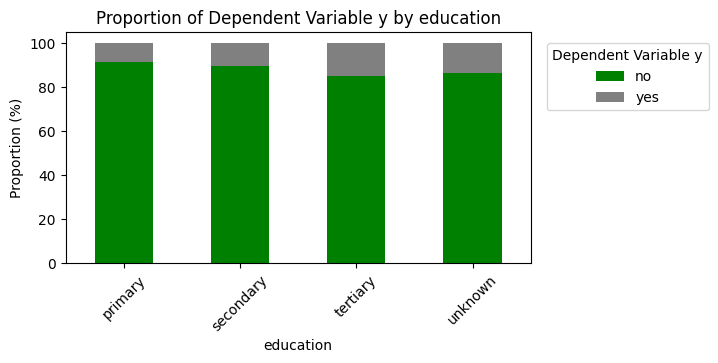

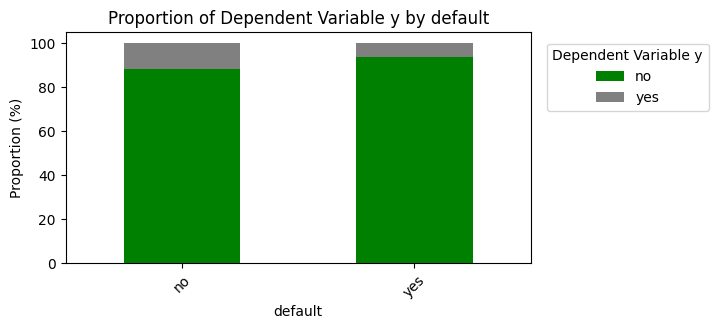

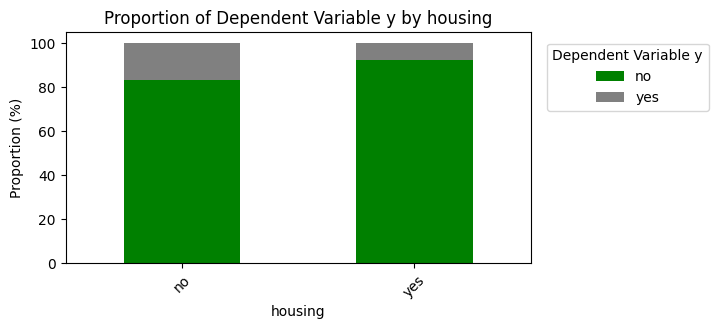

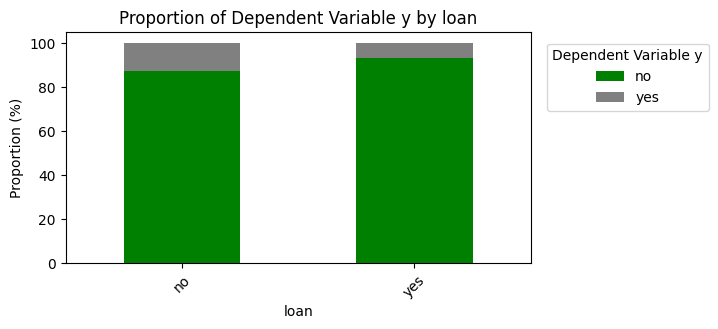

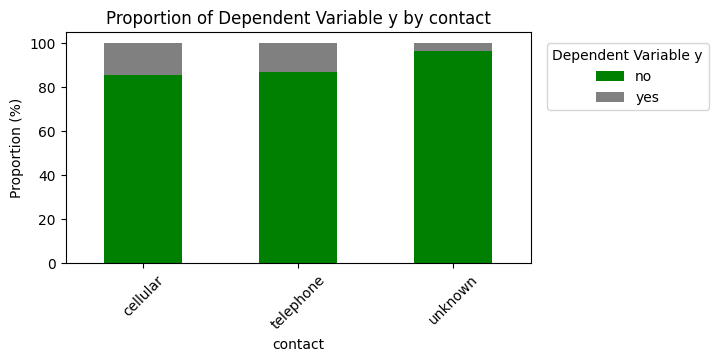

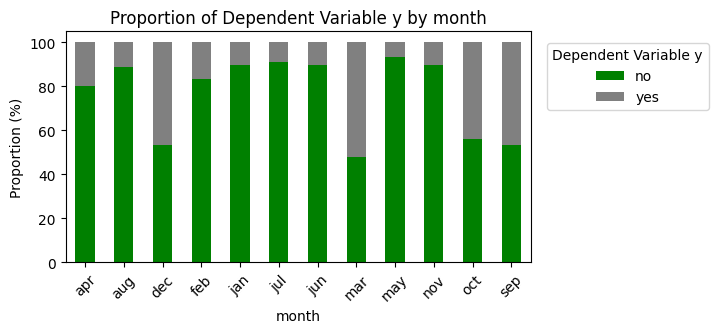

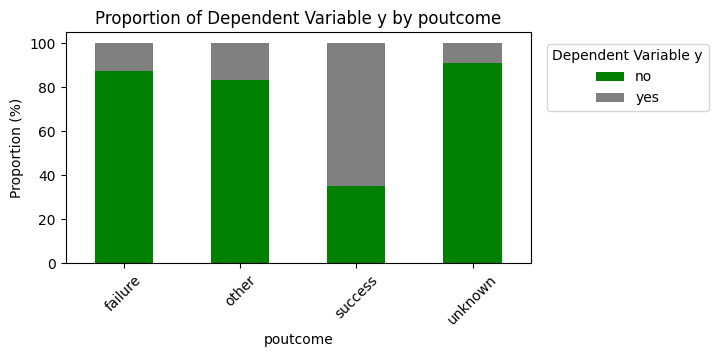

In [17]:
for col in categorical_cols:
    ctab = pd.crosstab(df[col], df["y"], normalize="index") * 100
    ctab.plot(kind="bar", stacked=True, figsize=(6, 3), color=['green', 'gray'])
    plt.title(f"Proportion of Dependent Variable y by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion (%)")
    plt.xticks(rotation=45)
    plt.legend(title='Dependent Variable y', bbox_to_anchor=(1.02, 0.98), loc='upper left')
    plt.show()

##### Detaield Findings of Dependent Variable by Categorical Features
**Target Variable by Job**
- In every job category, “no” is the majority outcome, highlighting the class imbalance.
- The **imbalance is consistent** across job categories, with most bars heavily weighted toward “no,” although the “yes” share varies slightly.

 - Job may provide some predictive signal, but because the data is strongly skewed toward “no,” handling class imbalance (e.g., class weights or SMOTE) will be important during modeling.

 - Some job groups, such as **retired** and **student**, show a higher “yes” rate compared with groups like blue-collar and entrepreneur.

**Target Variable by martial**
- 'No' is the majority outcome across all marital categories, indicating class imbalance.
- The single group shows a slightly higher share of “yes” compared to married and divorced.

**Target Variable by education**
- 'No' dominates in every education group, but the share of “yes” is higher for tertiary and unknown than for primary and secondary (tertiary looks highest).

**Target Variable by default**
- Clients with default = no have a slightly higher “yes” subscription rate than clients with default = yes.
- Having a credit default is associated with a lower likelihood of subscribing to the term deposit.

**Target Variable by housing**
- Clients with housing = no have a slightly higher “yes” subscription proportion than clients with housing = yes.
- ven so, “no” remains the majority outcome in both housing-loan groups.


**Target Variable by loan**
- Clients without a personal loan show a higher subscription (“yes”) rate compared to clients with a loan, and the pattern is similar to the housing feature.


**Target Variable by cobtact**
- Cellular has the highest share of “yes” subscribers, telephone is slightly lower, and “unknown” has the lowest.

**Target Variable by month**
- Clear seasonality: March, September, and December show a higher share of “yes.”

- May and August are more heavily dominated by “no.”


**Target Variable by poutcome**

- A previous “success” outcome is strongly associated with a higher rate of “yes” subscriptions.

- Failure, other, and unknown outcomes are mostly “no”, so poutcome looks like one of the strongest categorical predictors.


##### Summary Insights: Dependent Variable by Categorical Features
 - After reviewing the categorical features, it is clear that most outcomes are “no” (not subscribed). This indicates a **strong class imbalance toward "no"**, which will need to be addressed during modeling.

 - These features show relatively stronger predictive signals than others:
   - **Putcome** is the most obvious one because 'success' strongly linked to 'yes'.
   - **Month** suggests seasonality, with some months (e.g., December, March, and September) showing higher “yes” rates.
   - **Contact Type** indicates that cellular is the most effective (and most commonly used) contact method.
  
- Financial features (**loan, housing, default**) suggest that clients with fewer debt obligations are slightly more likely to subscribe.

- Demographic features like **education** and **martial status** show only small differences across categories, and most categories still lean toward 'no'.



---

##### Dependebt variable Imbalance (y)
checking the distribution of the dependent variable (**yes vs no**)
These results reinforce the imbalance in y, suggesting SMOTE or class weighting may be necessary during modeling.

Class counts:
 y
no     39922
yes     5289
Name: count, dtype: int64
Class proportions (%):
 y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


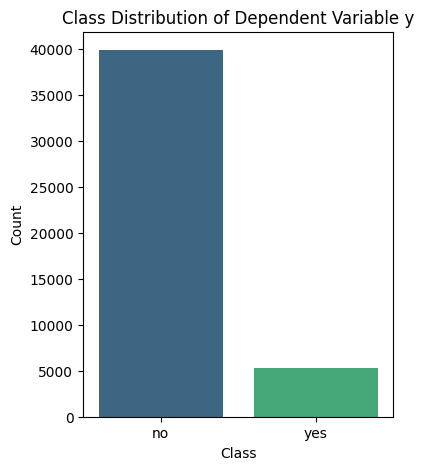

In [18]:
#Count values
class_count = df['y'].value_counts()
class_proportion = df['y'].value_counts(normalize=True) * 100
#print results
print("Class counts:\n", class_count)
print("Class proportions (%):\n", class_proportion)

#plot 
plt.figure(figsize=(4,5))
sns.barplot(x=class_count.index, y=class_count.values, palette='viridis',color='green')
plt.title('Class Distribution of Dependent Variable y') 
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

##### Results of Class Imbalance: 
The dataset is strongly imbalanced: “no” = 39,922 (88.3%) and “yes” = 5,289 (11.7%).
Because of this, a simple model could reach about 88% accuracy by predicting “no” for everyone.
So, we should consider imbalance-handling methods such as SMOTE, undersampling, or class weights to build a fairer model.

---

##### Feature Selection: Safe vs. Leaky Features
1. Safe Features (include in training)
These variables represent information available before the outcome of the call is known, making them safe for predictive modeling.
-  **Demographics**: age, job, marital, education.
-  **Financial Context**: balance (yearly average), housing (housing loan), loan (personal loan), default (credit in default).
-  **Campaign Metadata**: contact (communication type), day, month, campaign (number of contacts), previous (contacts before this campaign), poutcome (previous marketing outcome).
    
2. Leaky Features (exclude from training)
 - Duration: This feature must be dropped to prevent data leakage.
    - Definition: The dataset documentation defines duration strictly as the "last contact duration, in seconds".
    - Why it is leaky: This value is only known after the interaction has ended. As noted in the dataset methodology, the goal is to predict the success of the telemarketing call (variable y). Because duration is an outcome of the call itself rather than a precondition, it is not available at the moment of prediction in a real-world production environment.
    - Impact: Including duration would create an unrealistic model that relies on future information (e.g., if duration = 0, the outcome is almost certainly 'no'), leading to overly optimistic performance metrics that fail to generalize.[1][2]

-  References
- 1) Dataset Source: Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository.
- 2) Methodology: "A data-driven approach to predict the success of bank telemarketing," published in Decision Support Systems.

---


##### Correlation Heatmap (numeric features)
A correlation heatmap is computed only on numeric variables (e.g., age, balance, day, duration, campaign, pdays, previous). To include the dependent variable y in this analysis, it is converted to a numeric form (**y_num: yes = 1, no = 0**), which allows us to see how each numeric feature correlates with the outcome. Categorical variables (such as job or marital status) are not included in this heatmap and will be handled later using encoding methods.

Although duration often shows a strong correlation with y, it is a leaky feature because call duration is only known after the call ends. Therefore, it should be excluded from the final modeling feature set to avoid unrealistic performance.

               age   balance       day  duration  campaign     pdays  \
age       1.000000  0.097783 -0.009120 -0.004648  0.004760 -0.023758   
balance   0.097783  1.000000  0.004503  0.021560 -0.014578  0.003435   
day      -0.009120  0.004503  1.000000 -0.030206  0.162490 -0.093044   
duration -0.004648  0.021560 -0.030206  1.000000 -0.084570 -0.001565   
campaign  0.004760 -0.014578  0.162490 -0.084570  1.000000 -0.088628   
pdays    -0.023758  0.003435 -0.093044 -0.001565 -0.088628  1.000000   
previous  0.001288  0.016674 -0.051710  0.001203 -0.032855  0.454820   
y_num     0.025155  0.052838 -0.028348  0.394521 -0.073172  0.103621   

          previous     y_num  
age       0.001288  0.025155  
balance   0.016674  0.052838  
day      -0.051710 -0.028348  
duration  0.001203  0.394521  
campaign -0.032855 -0.073172  
pdays     0.454820  0.103621  
previous  1.000000  0.093236  
y_num     0.093236  1.000000  


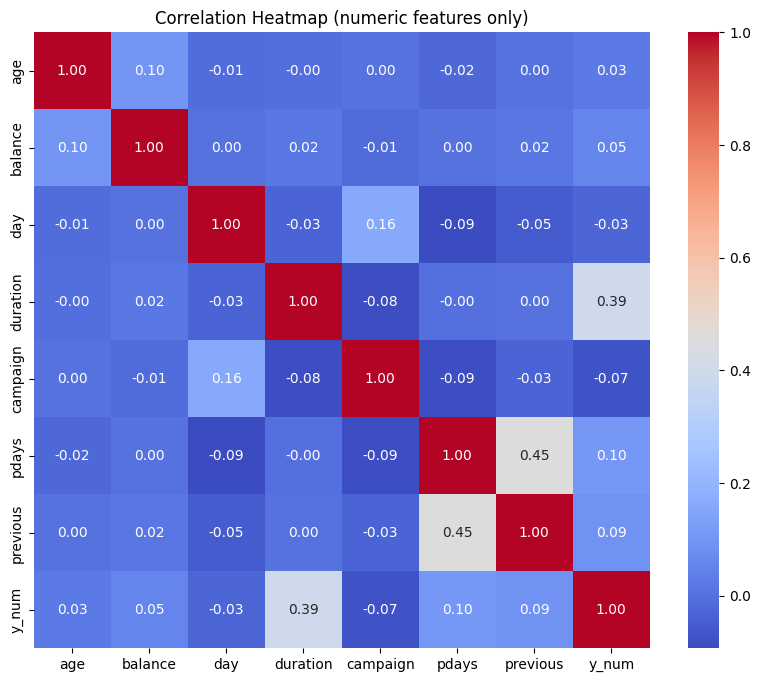

Correlation with Dependent variable (y_num):
duration    0.395
pdays       0.104
previous    0.093
balance     0.053
age         0.025
day        -0.028
campaign   -0.073
Name: y_num, dtype: float64


In [19]:
# Correlation matrix for numerical features

df_corr = df.copy()

if 'y' in df_corr.columns:
    df_corr['y_num'] = df_corr['y'].map({'yes': 1, 'no': 0})

# compute correlation only on numeric columns to avoid string-to-float conversion errors
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap (numeric features only)")
plt.show()

# compute correlation of numeric features with y_num
corr_with_target = corr_matrix["y_num"].drop("y_num").sort_values(ascending=False).round(3)
print("Correlation with Dependent variable (y_num):")
print(corr_with_target)

##### Results: Correlation Heatmap(Numeric Features)

Overall, most numeric features have very small correlations with each other and with the dependent variable (y_num), so the linear relationships look weak.

**Duration** has the strongest correlation with y_num (about 0.39), but it should be removed because it is a **leaky feature** (it is only known after the call finishes).

**pdays and previous** show a moderate positive correlation (about 0.45), which makes sense because clients who were contacted before often have a meaningful “days since last contact” value.

**For the other numeric features (age, balance, campaign, day),** correlations with y_num are close to zero, meaning they don’t show a strong direct linear link to subscription on their own.

**Modeling takeaway:** the strongest signals may come from nonlinear patterns, feature interactions, and categorical variables, so feature engineering (like recoding pdays or creating new campaign-related features) can help.

**Feature Engineering**
- **Campaign frequency per client:** the number of time the client has been cintacted in the current campaign 

- **Time since last contact**: pdays = how many days since the client was last contacted before this campaign.
 we can create from pdays:
 - Binary flag: was_contacted_before

- 1 (True) if the client was contacted before

- 0 (False) if the client was NOT contacted before (pdays == 999)

- Replace 999 with NaN so it becomes “missing” instead of “999 days”

In [20]:
# feature engineering on campaign
df_featured = df.copy()
df_featured['campaign_frequency'] = df_featured['campaign']

df_featured['campaign_frequency_log'] = np.log1p(df_featured['campaign_frequency']) 
df_featured.head(10)
# Time since last contact in days (pdays)
df_featured['was_contacted_before'] = np.where(df_featured['pdays'] != -1, 1, 0)
df_featured['days_since_contact'] = df_featured['pdays'].replace(-1, np.nan)
df_featured.head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,campaign_frequency,campaign_frequency_log,was_contacted_before,days_since_contact
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,-1,0,unknown,no,1,0.693147,0,NaN
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,151,1,-1,0,unknown,no,1,0.693147,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,76,1,-1,0,unknown,no,1,0.693147,0,NaN
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,92,1,-1,0,unknown,no,1,0.693147,0,NaN
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,198,1,-1,0,unknown,no,1,0.693147,0,NaN
5,35,management,married,tertiary,no,231,yes,no,unknown,5,...,139,1,-1,0,unknown,no,1,0.693147,0,NaN
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,...,217,1,-1,0,unknown,no,1,0.693147,0,NaN
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,...,380,1,-1,0,unknown,no,1,0.693147,0,NaN
8,58,retired,married,primary,no,121,yes,no,unknown,5,...,50,1,-1,0,unknown,no,1,0.693147,0,NaN
9,43,technician,single,secondary,no,593,yes,no,unknown,5,...,55,1,-1,0,unknown,no,1,0.693147,0,NaN


##### Results: Feature Engineering
**Campaign frequency:**
 added campaign_frequency_log because campaign is highly right-skewed. Applying a log transform compresses extreme values, reduces the influence of very large contact counts, and makes differences between low contact levels easier to compare.

**Time since last contact (pdays):**
* In this dataset, `pdays = -1` indicates **no previous contact** (instead of 999 in other versions).
* Created `days_since_contact` by recoding `-1` to `NaN` for clearer numeric interpretation.
* Added `was_contacted_before` as a binary flag (1 = previously contacted, 0 = no prior contact).
* This separates “no prior contact” from real day counts and makes the feature easier to use in modeling.




##### Visualization of engineered features

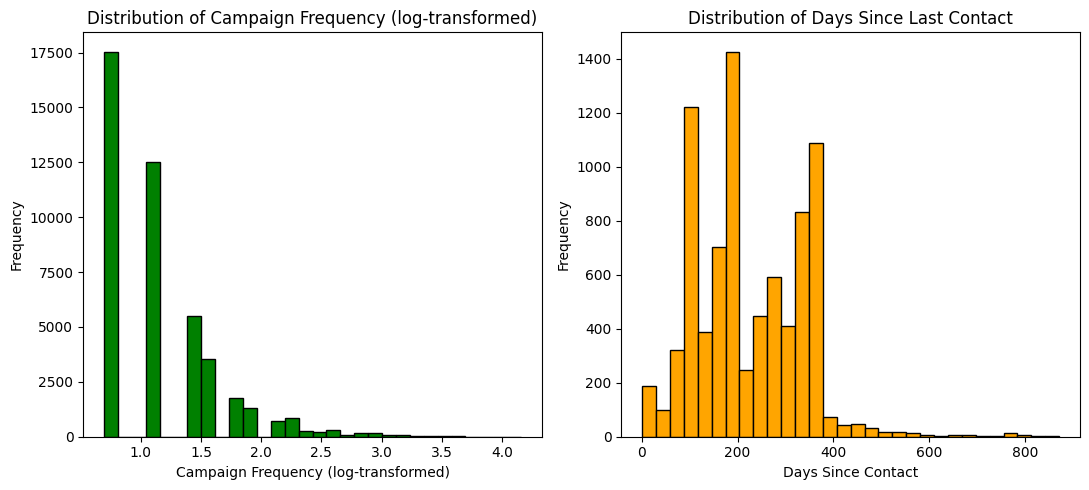

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

#Histogram of campaign_frequency(log_transformed)
axes[0].hist(df_featured['campaign_frequency_log'], bins=30, color='green', edgecolor='black')
axes[0].set_title('Distribution of Campaign Frequency (log-transformed)')
axes[0].set_xlabel('Campaign Frequency (log-transformed)')
axes[0].set_ylabel('Frequency')

#Histogram of days_since_contact
axes[1].hist(df_featured['days_since_contact'].dropna(), bins=30, color='orange', edgecolor='black')
axes[1].set_title('Distribution of Days Since Last Contact')
axes[1].set_xlabel('Days Since Contact')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

##### Results: Engineered Feature Distributions
**Campaign frequency (log-transformed)**:
* The original campaign variable is highly right-skewed: most clients were contacted 1–2 times, while a few were contacted many times.

* Applying log(1 + x) compresses large values, making the distribution easier to interpret and reducing the influence of extreme values.

**Days since last contact**:
* Most clients have no previous contact (shown as NaN after recoding -1) or were contacted again within a relatively small number of days.

* A smaller group shows very long gaps between contacts.

* Seperating “no prior contact” from true day values makes this feature clearer and more useful for modeling.



---

##### Synthetic Minority Over-sampling Technique (SMOTE)
SMOTE helps handle class imbalance by creating synthetic (new) training samples for the minority class. This increases the number of minority examples and can help the model learn a better decision boundary.

There are multiple SMOTE variants. For this project, SMOTE-NC (Nominal-Continuous) is a good option because it is designed for datasets that include both numeric and categorical features.

**How SMOTE-NC works (high level)**:

First, it separates features into **continuous** vs **categorical**.

For continuous features, it creates synthetic points using interpolation (similar to standard SMOTE).

For categorical features, it does not interpolate; instead, it assigns the most common category among the nearest neighbors.

The result is a more balanced dataset while keeping categorical values valid.

**Reference** :

GeeksforGeeks. SMOTE for Imbalanced Classification with Python.
https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

**hints:**
I plan to apply SMOTE/SMOTE-NC only on the training set after the train–test split, so synthetic samples don’t leak information into the test set.

**Class Weights**

In [22]:
y1 = df["y"].copy()

classes = y1.unique()
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y1)

class_weights = dict(zip(classes, weights))
print("Computed Class Weights:", class_weights)

Computed Class Weights: {'no': 0.566241671258955, 'yes': 4.274059368500661}


**Interpretstion of Class Weights:**
* The class weight for ‘yes’ is 4.27 because this class is much rarer than ‘no’, so the model upweights it. The weight for ‘no’ is 0.56 because it is the majority class and is therefore downweighted.

---

##### Data Preprocessing & Model Development

**Encode categorical variables**

In [23]:
categorical_cols =df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Variables:", categorical_cols)

for col in categorical_cols:
    print(f"Unique categories in '{col}': {df[col].nunique()}")
    print(f"\n{df[col].unique()}")


Categorical Variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Unique categories in 'job': 12

['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique categories in 'marital': 3

['married' 'single' 'divorced']
Unique categories in 'education': 4

['tertiary' 'secondary' 'unknown' 'primary']
Unique categories in 'default': 2

['no' 'yes']
Unique categories in 'housing': 2

['yes' 'no']
Unique categories in 'loan': 2

['no' 'yes']
Unique categories in 'contact': 3

['unknown' 'cellular' 'telephone']
Unique categories in 'month': 12

['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Unique categories in 'poutcome': 4

['unknown' 'failure' 'other' 'success']
Unique categories in 'y': 2

['no' 'yes']


In [24]:
#Test run : encoding + scaling

# Take a small sample (first 100 rows)
df_sample = df.head(100)

# Split into features(X) and target(y)
X_sample = df_sample.drop("y", axis=1) # all the columns except target
y_sample = df_sample["y"].copy() # target column 

# Identify categorical and numerical columns
categorical_cols = X_sample.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_sample.select_dtypes(include=['number']).columns.tolist()

# Preprocessor: one-hot encoding for categorical, standard scaling for numerical
# OneHotEncoder(...): This converts text categories into 0/1 columns.
# handle_unknown="ignore":If the test data has a category never seen before, don’t crash — just put 0s.
# sparse_output=False : Return a normal dense array (easier to print), not a sparse matrix.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]                                                               
)

pipe = Pipeline(steps=[("preprocessor", preprocessor)])

# Fit + transform the sample features   
X_sample_transformed = pipe.fit_transform(X_sample)
print("Original shape:", X_sample.shape)
print("Transformed shape:", X_sample_transformed.shape)

print(X_sample_transformed[:10])


Original shape: (100, 16)
Transformed shape: (100, 32)
[[ 1.14264846  0.82285378  0.         -0.14729046 -0.29488391  0.
   0.          0.          0.          0.          1.          0.
   0.          0.          0.          0.          0.          1.
   0.          0.          0.          1.          0.          1.
   0.          0.          1.          1.          0.          1.
   1.          1.        ]
 [-0.23522221 -0.33168762  0.         -0.47801    -0.29488391  0.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   1.          0.          1.          0.          0.          1.
   0.          0.          1.          1.          0.          1.
   1.          1.        ]
 [-1.31783487 -0.34643342  0.         -0.7035006  -0.29488391  0.
   0.          0.          0.          1.          0.          0.
   0.          0.          0.          0.          0.          1.
   0.          0.          1.    

In [25]:
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
print(len(feature_names))
print(feature_names)


32
['num__age' 'num__balance' 'num__day' 'num__duration' 'num__campaign'
 'num__pdays' 'num__previous' 'cat__job_admin.' 'cat__job_blue-collar'
 'cat__job_entrepreneur' 'cat__job_management' 'cat__job_retired'
 'cat__job_self-employed' 'cat__job_services' 'cat__job_technician'
 'cat__job_unknown' 'cat__marital_divorced' 'cat__marital_married'
 'cat__marital_single' 'cat__education_primary' 'cat__education_secondary'
 'cat__education_tertiary' 'cat__education_unknown' 'cat__default_no'
 'cat__default_yes' 'cat__housing_no' 'cat__housing_yes' 'cat__loan_no'
 'cat__loan_yes' 'cat__contact_unknown' 'cat__month_may'
 'cat__poutcome_unknown']


##### Define features/target and column group

In [26]:
# .str.lower() makes sure it’s lowercase ("Yes" vs "yes" handled).
# .eq('yes') returns True for “yes”, False otherwise.
# .astype(int) converts those booleans into 1 and 0.
# End result: y is a column of 1s and 0s (1 = subscribed, 0 = not)
Y = df['y'].str.lower().eq('yes').astype(int)

# all variables except  dependent variable y become X
X = df.drop(columns=['y'])

# split the features into numerical and categorical
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("X shape:", X.shape)
print("Y shape:", Y.shape)


Numerical Columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
X shape: (45211, 16)
Y shape: (45211,)


---

##### Begin Preprocessing for Modeling

* Drop leakage feature **duration**

In [27]:
Y = df['y'].str.lower().eq('yes').astype(int)

X = df.drop(columns=['y','duration'])      # drop 'duration' as it is not known before the call is performed
print("X shape after dropping 'duration':", X.shape)
print("Y shape:", Y.shape)    


X shape after dropping 'duration': (45211, 15)
Y shape: (45211,)


##### Split dataset into training (70%), validation(15%), and test(15%) sets

In [28]:
X_train,X_temporary,Y_train,Y_temporary = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

X_val,X_test,Y_val,Y_test = train_test_split(X_temporary, Y_temporary, test_size=0.50, random_state=42, stratify=Y_temporary)
print("Training set shape:", X_train.shape, Y_train.shape)
print("Validation set shape:", X_val.shape, Y_val.shape)
print("Test set shape:", X_test.shape, Y_test.shape)

Training set shape: (31647, 15) (31647,)
Validation set shape: (6782, 15) (6782,)
Test set shape: (6782, 15) (6782,)


**Label configuration**

In [29]:
POS_LABEL = 1
labels = [1,0] # focus the confusion matrix to show results in that order
target_names = ['yes','no']  # 0: No, 1: Yes

def matrics (y_true, probs, threshold):
    y_pred = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(y_true, y_pred, pos_label=POS_LABEL)

    rec = recall_score(y_true, y_pred, pos_label=POS_LABEL)

    f1 = f1_score(y_true, y_pred, pos_label=POS_LABEL)

    roc_auc = roc_auc_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=target_names, labels=labels)
    
    print("Accuracy: {:.5f}".format(acc))
    print("Precision: {:.5f}".format(prec))
    print("Recall: {:.5f}".format(rec))
    print("F1-score: {:.5f}".format(f1))
    print("ROC-AUC: {:.45}".format(roc_auc))
    
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names, labels=labels))
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

**column lists**

In [30]:
numeric_cols= X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols= X_train.select_dtypes(include=['object']).columns.tolist()
print("Numerical Columns in X_train:", numeric_cols)
print("Categorical Columns in X_train:", categorical_cols)

Numerical Columns in X_train: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical Columns in X_train: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


##### Scale numeric features

In [31]:
#Use StandardScaler or MinMaxScaler for numerical features
# Fit on training data only, transform train, val, test
#If you recalculated mean/std separately on validation or test, you would “peek” at those sets. 
# That’s data leakage and can make results look better than they really are.
# fit on train → learns mean/std
#transform on val/test → applies train mean/std

scalar = StandardScaler()
X_train_numeric_scaled = pd.DataFrame(scalar.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index)

X_val_numeric_scaled = pd.DataFrame(scalar.transform(X_val[numeric_cols]), columns=numeric_cols, index=X_val.index)

X_test_numeric_scaled = pd.DataFrame(scalar.transform(X_test[numeric_cols]), columns=numeric_cols, index=X_test.index)

print("Numerical shape after scaling:", X_train_numeric_scaled.shape, X_val_numeric_scaled.shape, X_test_numeric_scaled.shape)
print("Scaled numerical features in X_train:")
print(X_train_numeric_scaled.head())

Numerical shape after scaling: (31647, 6) (6782, 6) (6782, 6)
Scaled numerical features in X_train:
            age   balance       day  campaign     pdays  previous
13382 -0.930461 -0.443813 -0.817039 -0.566850 -0.410038 -0.234774
32641 -0.553871 -0.380625  0.143236 -0.566850 -0.410038 -0.234774
3991  -1.589493 -0.419059  0.023201 -0.244783 -0.410038 -0.234774
8068  -0.553871 -0.418082 -1.657280 -0.244783 -0.410038 -0.234774
27484 -0.365576 -0.409939  0.623373 -0.244783  1.175153  1.371081


Results:  
* only the numeric columns were scaled.
    - trainig set: it has 31,674 rows(samples) and 6 numeric features(columns).
    - validation set: it has 6,782 rows and 6 numeric columns.
    - test_set: it has 6,782 rows and 6 numeric features.



##### One-hot on Train

In [32]:
X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=False)

#
X_val_cat = pd.get_dummies(X_val[categorical_cols], drop_first=False).reindex(columns=X_train_cat.columns, fill_value=0)

X_test_cat = pd.get_dummies(X_test[categorical_cols], drop_first=False).reindex(columns=X_train_cat.columns, fill_value=0)

#print(X_train_cat.head(5))

print("Categorical shape after one-hot encoding:", X_train_cat.shape, X_val_cat.shape, X_test_cat.shape)



Categorical shape after one-hot encoding: (31647, 44) (6782, 44) (6782, 44)


In [33]:
# Final column order 
import pprint
feature_names = numeric_cols + X_train_cat.columns.tolist()
pprint.pprint(feature_names)
print("Final feature names count:", len(feature_names))

['age',
 'balance',
 'day',
 'campaign',
 'pdays',
 'previous',
 'job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_divorced',
 'marital_married',
 'marital_single',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'default_no',
 'default_yes',
 'housing_no',
 'housing_yes',
 'loan_no',
 'loan_yes',
 'contact_cellular',
 'contact_telephone',
 'contact_unknown',
 'month_apr',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown']
Final feature names count: 50


##### Create the Final dataset(ready for ML)

In [34]:

X_train_final = pd.concat([X_train_numeric_scaled, X_train_cat], axis=1)[feature_names]

X_val_final = pd.concat([X_val_numeric_scaled, X_val_cat], axis=1)[feature_names]

X_test_final = pd.concat([X_test_numeric_scaled, X_test_cat], axis=1)[feature_names]
print(X_train_final.head(5))
print("Final shapes :", X_train_final.shape, X_val_final.shape, X_test_final.shape)

            age   balance       day  campaign     pdays  previous  job_admin.  \
13382 -0.930461 -0.443813 -0.817039 -0.566850 -0.410038 -0.234774       False   
32641 -0.553871 -0.380625  0.143236 -0.566850 -0.410038 -0.234774       False   
3991  -1.589493 -0.419059  0.023201 -0.244783 -0.410038 -0.234774       False   
8068  -0.553871 -0.418082 -1.657280 -0.244783 -0.410038 -0.234774       False   
27484 -0.365576 -0.409939  0.623373 -0.244783  1.175153  1.371081       False   

       job_blue-collar  job_entrepreneur  job_housemaid  ...  month_jun  \
13382            False             False          False  ...      False   
32641            False             False          False  ...      False   
3991              True             False          False  ...      False   
8068              True             False          False  ...       True   
27484            False             False          False  ...      False   

       month_mar  month_may  month_nov  month_oct  month_sep  

Safety check #1: Are numeric columns scaled correctly?

In [35]:
print(X_train_numeric_scaled.agg(['mean', 'std']).round(3))

      age  balance  day  campaign  pdays  previous
mean  0.0      0.0  0.0       0.0   -0.0      -0.0
std   1.0      1.0  1.0       1.0    1.0       1.0


Safety check #2: are one-hot columns really 0/1?

In [36]:
ohe_columns = [c for c in feature_names if c not in numerical_cols]
print("One-hot encoded(train):",
      X_train_final[ohe_columns].min().min()== 0 and X_train_final[ohe_columns].max().max()==1
      )
print("One-hot encoded(val):",
      X_val_final[ohe_columns].min().min()== 0 and X_val_final[ohe_columns].max().max()==1)
print("One-hot encoded(test):",
        X_test_final[ohe_columns].min().min()== 0 and X_test_final[ohe_columns].max().max()==1)

One-hot encoded(train): True
One-hot encoded(val): True
One-hot encoded(test): True


Safety check #3: any missing values (NaNs)?

In [37]:
print("All False means no missing values in any dataset:",
X_train_final.isna().any().any(),
X_val_final.isna().any().any(),
X_test_final.isna().any().any()
)

All False means no missing values in any dataset: False False False


##### Results: 
* Create thr final dataset:
  - Final shapes: (31647, 50) (6782, 50) (6782, 50)
  - Training set (X_train_final) has 31,647 rows and 50 features (columns).
  - Validation set (X_val_final) has 6,782 rows and 50 features.
  - Test set (X_test_final) has 6,782 rows and 50 features.

* Safety check #1:
  - Shows the mean and sd for each numeric features after scaling.
  - All means are ~0 and all standard deviations are ~1

 * Safety check #2: 
    - The one-hot encoded columns also look correct in train, validation and test sets, with values restricted to 0/1 (OHE binary (train): True).

* Safety check #3:
   - Confirms there are no missing values (NaNs) in any of train, validationa and test sets


##### Summary stats for SCALED numeric features (TRAIN)

In [38]:
summary_numeric= X_train_numeric_scaled if "X_train_numeric_scaled" in globals() else X_train_final[numerical_cols]

report = summary_numeric.describe().round(3)
print(report)

             age    balance        day   campaign      pdays   previous
count  31647.000  31647.000  31647.000  31647.000  31647.000  31647.000
mean       0.000      0.000      0.000      0.000     -0.000     -0.000
std        1.000      1.000      1.000      1.000      1.000      1.000
min       -2.154     -3.056     -1.777     -0.567     -0.410     -0.235
25%       -0.742     -0.420     -0.937     -0.567     -0.410     -0.235
50%       -0.177     -0.297      0.023     -0.245     -0.410     -0.235
75%        0.670      0.021      0.623      0.077     -0.410     -0.235
max        5.095     32.820      1.824     19.401      8.339    110.168


---

##### Train Baseline Model (Logistic Regression)

**A1-   Logistic Regression (Baseline, Unweighted)**
-  Fit + cache VAL probabilities 
-  Goal: fit on TRAIN only (no leakage) and cache validation probabilities for threshold sweeps.

In [39]:
Model_Name = "Logistic Regression (unweighted)"
Model_Tag = 'LR_UNW'

LOGISTIC_REGRESSION_UNWEIGHTED = LogisticRegression(
    solver='lbfgs',     # reliable default optimizer for Logistic Regression 
    max_iter=1000,      # Maximum number of iterations to converge
    random_state=42     # makes results reproducible
)

# Safety Checks
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

# Fit the model on training data
fit_model = LOGISTIC_REGRESSION_UNWEIGHTED.fit(X_train_final, Y_train)

# Get probabilities on validation set
probs_val = LOGISTIC_REGRESSION_UNWEIGHTED.predict_proba(X_val_final)[:, 1]  # probabilities for the positive class
print(probs_val)

# Cache/save these results in named variables (fixed quoting and variable name)
globals()[f"probs_val_{Model_Tag}"] = probs_val
# store model under both keys used elsewhere if needed
globals()[f"model{Model_Tag}"] = LOGISTIC_REGRESSION_UNWEIGHTED
globals()[f"model_{Model_Tag}"] = LOGISTIC_REGRESSION_UNWEIGHTED

print(f"[Ok] '{Model_Name}' fitted - cached as probs_val_{Model_Tag}.")


[0.06534934 0.12062205 0.15671574 ... 0.05546141 0.07500131 0.13297223]
[Ok] 'Logistic Regression (unweighted)' fitted - cached as probs_val_LR_UNW.



 #### Logistic Regression (Baseline, Unweighted): Threshold
**A2- Threshold Sweep/Lock Best Threshold**
 - What threshold gives me the best recall, but still acceptable precision?
    * Test multiple thresholds on the validation set and track key metrics.
    * Choose and lock the threshold that maximizes recall while meeting a minimum precision (or use best F1 if none meet it).
    * Save the locked threshold for consistent comparisons later.


In [40]:
# 2

Model_Tag = 'LR_UNW'

# Load the cached probabilities
probs_val = globals()[f"probs_val_{Model_Tag}"]

# Use the existing validation target (Y_val) and ensure it's numeric 0/1
y_val_b = np.array(Y_val, dtype=int)

# Define threshold to test
threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)

#Set a minimum precision rule
precision_floor = 0.30 # I don’t accept thresholds where precision is below 0.30.

#Compute metrics for each threshold
metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)

    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])

# IMPORTANT: column names MUST match the order above
metrics_df = pd.DataFrame(
    metrics,
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)

display(metrics_df)

# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
# 2) if none meet the rule, use best F1
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None

if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")



,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.665438,0.712846,0.217108,0.332843,0.384400
1,0.11,0.708935,0.680101,0.238938,0.353635,0.333235
2,0.12,0.751843,0.634761,0.265683,0.374582,0.279711
3,0.13,0.787083,0.599496,0.297129,0.397329,0.236214
4,0.14,0.810528,0.566751,0.323508,0.411899,0.205102
5,0.15,0.829549,0.532746,0.350166,0.422577,0.178119
6,0.16,0.841935,0.505038,0.371296,0.427962,0.159245
7,0.17,0.855058,0.486146,0.401665,0.439886,0.141699
8,0.18,0.861693,0.468514,0.418919,0.442331,0.130935
9,0.19,0.868623,0.454660,0.440781,0.447613,0.120761



[LOCKED] THRESH_LR_UNW = 0.14


##### Results: 
for this unweighted Logistic Regression model, we will predict “yes” if the predicted probability ≥ 0.14, else = predict no.

---

##### A3 - ogistic Regression Confusion Matrix (Unweighted, Validation)
- Confusion matrix for the unweighted Logistic Regression on the validation set.

- Shows counts of TP, FP, TN, and FN, giving a clearer picture than accuracy alone.
Especially useful for checking how well the model detects the minority class (yes), since missed subscribers appear as false negatives (FN).

- The pattern in this matrix supports threshold selection and highlights where the model needs improvement.

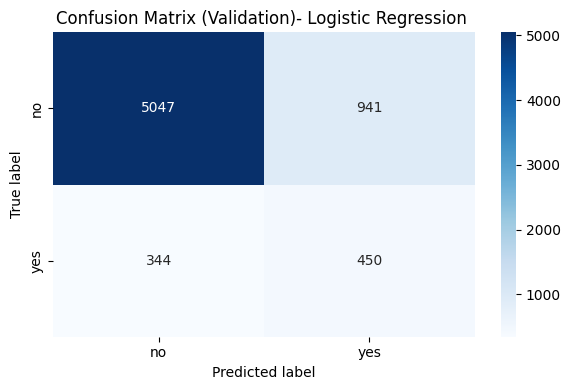

In [41]:


# Display Confusion Matrix(Validation)
probs = globals().get("probs_val_LR_UNW")
thresh = globals().get("THRESH_LR_UNW")
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Plot confusion matrix
cm = confusion_matrix(y_val_b,y_pred)
labels = ['no','yes']  # 0: No, 1: Yes
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Validation)- Logistic Regression ')
plt.tight_layout()
plt.show()

##### Results
The model captures about 57% of actual subscribers (450/794) but only about 32% of its ‘yes’ predictions are correct (450/1391). This reflects the class imbalance and the need for further tuning or imbalance handling


#### B1- Logistic Regression (Baseline, Balanced Class Weights)
- class_weight="balanced" to reduce the impact of class imbalance.

- This automatically gives more weight to the minority class (“yes”) and less to the majority class (“no”), so recall often increases, while precision/accuracy may decrease slightly.

- Evaluate on the validation set and compare results against the unweighted baseline.

In [42]:
Model_Name = "Logistic Regression(balanced)" # using class_weight='balanced'
Model_Tag = 'lr_bal'

# Define the model 
model_lr_bal = LogisticRegression(solver='lbfgs',
                                 max_iter=1000,   
                                 random_state=42,
                                class_weight='balanced')  

#safety Checks

assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

 # fit model
model_lr_bal.fit(X_train_final, Y_train)

# validation probabilities
probs_val = model_lr_bal.predict_proba(X_val_final)[:, 1]  
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model{Model_Tag}"] = model_lr_bal
print(f"[Ok] '{Model_Name}' fitted - cached as probs_val_{Model_Tag}.")




[Ok] 'Logistic Regression(balanced)' fitted - cached as probs_val_lr_bal.


 #### Logistic Regression (Baseline, Balanced Class Weights): Threshold
**B2- Threshold Sweep/Lock Best Threshold**
- Baseline Logistic Regression using class_weight="balanced" (no hyperparameter tuning).

- Run a threshold sweep on the validation set and lock the best threshold based on the chosen rule (e.g., recall with a precision floor).

- Report accuracy, precision, recall, and F1, then compare results with the unweighted baseline for later models.

In [43]:
# B2
Model_Tag = 'lr_bal'

# Load the cached probabilities
probs_val = globals()[f"probs_val_{Model_Tag}"]
# Use the existing validation target (Y_val) and ensure it's numeric 0/1
y_val_b = np.array(Y_val, dtype=int) 
# Define threshold to test
threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
#Set a minimum precision rule
precision_floor = 0.30 # I don’t accept thresholds where precision is below 0.30.
#Evaluate metrics for each threshold
metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)

    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])

metrics_df = pd.DataFrame(
    metrics,
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor        
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]  
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None 
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.124152,0.998741,0.117796,0.210736,0.992628
1,0.11,0.128576,0.998741,0.118323,0.211580,0.988204
2,0.12,0.134031,0.998741,0.118980,0.212629,0.982748
3,0.13,0.141699,0.997481,0.119800,0.213910,0.974786
4,0.14,0.153495,0.992443,0.120803,0.215389,0.961811
5,0.15,0.167355,0.991184,0.122452,0.217975,0.947656
6,0.16,0.185491,0.984887,0.124245,0.220655,0.928045
7,0.17,0.202890,0.978589,0.126014,0.223276,0.909171
8,0.18,0.220142,0.974811,0.128082,0.226415,0.891035
9,0.19,0.232380,0.969773,0.129368,0.228283,0.877617



[LOCKED] THRESH_LR_BAL = 0.50


#### B3- Logistic Regression Confusion Matrix (baselinebalanced class weights, validation)
- Shows the validation confusion matrix for Logistic Regression with class_weight="balanced".

- Useful for seeing how weighting changes TP/FP/TN/FN compared to the unweighted baseline.

- Helps confirm whether the model is still missing too many real “yes” cases and informs the next tuning steps.

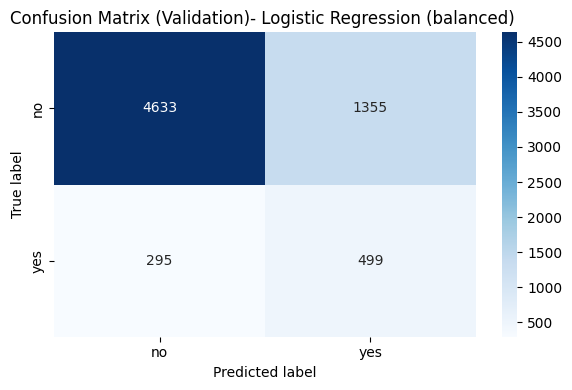

In [44]:
# plot confusion matrix(validation)
probs = globals().get("probs_val_lr_bal")  
thresh = globals().get("THRESH_LR_BAL")
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Plot confusion matrix
cm = confusion_matrix(y_val_b,y_pred)
labels = ['no','yes']  # 0: No, 1: Yes
plt.figure(figsize=(6,4))   
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Validation)- Logistic Regression (balanced) ')     
plt.tight_layout()
plt.show()

**Results**
Balanced Logistic Regression catches more **“yes”** customers (TP=499, recall ≈ 63%) but creates many extra **false alarms** (FP=1355), so precision drops. Overall, it trades higher recall for lower accuracy/precision compared to the unweighted model.



##### Logistic Regression – Quick Comparison (Unweighted vs Balanced)
 - Summarize accuracy, precision, recall, and F1 for both models in one table.

- Add both confusion matrices to show how TP/FP/TN/FN change after class weighting.

- Use the comparison to decide whether class weights improve the minority class (“yes”) enough to keep.

In [45]:
probs_a_unw = globals().get("probs_val_LR_UNW")
probs_b_bal = globals().get("probs_val_lr_bal")
y_val_b = np.array(Y_val, dtype=int)
threshold_a_unw = globals().get("THRESH_LR_UNW")
threshold_b_bal = globals().get("THRESH_LR_BAL")

def evaluate_model(probs, thresh):
    if probs is None:
        raise ValueError("probabilities array is None — check globals() name.")
    if thresh is None:
        raise ValueError("threshold is None — check globals() name.")
    y_pred = (probs >= thresh).astype(int)
    return {
        "threshold": float(thresh),
        "recall":    recall_score(y_val_b, y_pred, zero_division=0),
        "precision": precision_score(y_val_b, y_pred, zero_division=0),
        "f1":        f1_score(y_val_b, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_val_b, y_pred),
        "pred_pos_rate": float(y_pred.mean())
    }

final = [
    {"model": "Logistic Regression (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)},
    {"model": "Logistic Regression (balanced)",   **evaluate_model(probs_b_bal, threshold_b_bal)}
]

results = pd.DataFrame(final, columns=["model","threshold","recall","precision","f1","accuracy","pred_pos_rate"]).round(3)
display(results)

,model,threshold,recall,precision,f1,accuracy,pred_pos_rate
0,Logistic Regression (unweighted),0.14,0.567,0.324,0.412,0.811,0.205
1,Logistic Regression (balanced),0.50,0.628,0.269,0.377,0.757,0.273


#### C1 - Decision Tree (Baseline, Unweighted) — Fit + Cache Validation Probabilities
- Train a baseline Decision Tree without class weights.

- Predict and save validation probabilities for later threshold tuning.

- Report accuracy, precision, recall, and F1 on the validation set, and plot the confusion matrix.

- Note key observations to compare with weighted/tuned tree variants later.

In [46]:
Model_Name = 'Decision Tree- Unweighted'
Model_Tag = 'DT_UNW'

model_dt_unw = DecisionTreeClassifier(random_state=42)

assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

model_dt_unw.fit(X_train_final, Y_train)
probs_val = model_dt_unw.predict_proba(X_val_final)[:, 1]

# Cache/save these results so later cells can read `probs_val_DT_UNW`
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_dt_unw
print(f"[Ok] '{Model_Name}' fitted - cached as probs_val_{Model_Tag}.")

[Ok] 'Decision Tree- Unweighted' fitted - cached as probs_val_DT_UNW.


#### Decision Tree Classifier (Baseline, unweighted): Threshold
**C2- Threshold Sweep/Lock Best Threshold**
- Use the fitted baseline tree (no hyperparameter tuning yet).

- Sweep probability thresholds on the validation set and lock the best one using the chosen rule (e.g., recall with a precision floor).

- Report accuracy, precision, recall, and F1 at the locked threshold, then plot the confusion matrix.

- Record key takeaways to compare against tuned/weighted tree versions later.

In [47]:
Model_Tag = 'DT_UNW'
probs_val = globals()[f"probs_val_{Model_Tag}"]

y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30
metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])

metrics_df = pd.DataFrame(
    metrics,
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)

# pick best rows from the metrics_df (not the main df)
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]

# guard: rows meeting precision floor (use proper column name)
guard = metrics_df[metrics_df["Precision"] >= precision_floor]

recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None

if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.836479,0.331234,0.312723,0.321713,0.124005
1,0.11,0.836479,0.331234,0.312723,0.321713,0.124005
2,0.12,0.836479,0.331234,0.312723,0.321713,0.124005
3,0.13,0.836479,0.331234,0.312723,0.321713,0.124005
4,0.14,0.836479,0.331234,0.312723,0.321713,0.124005
5,0.15,0.836479,0.331234,0.312723,0.321713,0.124005
6,0.16,0.836479,0.331234,0.312723,0.321713,0.124005
7,0.17,0.836479,0.331234,0.312723,0.321713,0.124005
8,0.18,0.836479,0.331234,0.312723,0.321713,0.124005
9,0.19,0.836479,0.331234,0.312723,0.321713,0.124005



[LOCKED] THRESH_DT_UNW = 0.10


##### C3 - Decision Tree- Classifier Confusion Matrix (Unweighted, validation)

- Displays the confusion matrix for the unweighted Decision Tree on the validation set.

- Makes TP, FP, TN, and FN easy to compare, not just overall accuracy.

- Focus on recall for the minority class (“yes”) to see how many subscribers are being missed (FN).

- Use these results to support threshold choice and guide the next model improvements.

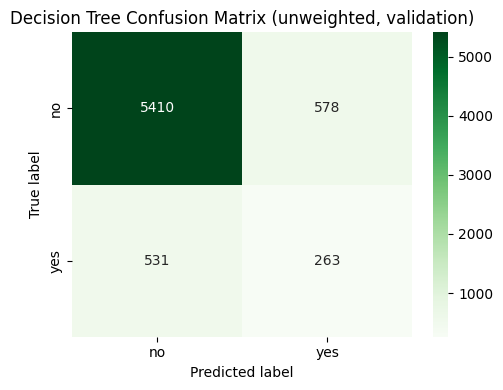

In [48]:
# try common global names for the cached probabilities (handle case-variants)
probs = globals()["probs_val_DT_UNW"] 
thresh = globals()["THRESH_DT_UNW"]
y_val_b = np.array(Y_val, dtype=int)    # ensure binary array
y_pred = (probs >= thresh).astype(int)  # predictions at locked threshold

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']

# plot confusion matrix 
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Decision Tree Confusion Matrix (unweighted, validation)")
plt.tight_layout()
plt.show()






#### D1 - Decision Tree (Baseline, Balanced) — Fit + Cache Validation Probabilities



- Decision Tree with class_weight='balanced' to handle class imbalance.
- Evaluate on validation set and cache predicted probabilities for later threshold tuning.
- Check metrics: accuracy, precision, recall, F1-score.
- Plot confusion matrix.
- Document results and insights.

In [49]:
Model_Name = "Decision Tree (balanced)" 
Model_Tag = "DT_BAL"

# Construct Model
model_DT_Bal = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"      
)

# Safety check 
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

# Fit model
model_DT_Bal.fit(X_train_final, Y_train)

# Cache validation probabilities (probs_val_<MODEL_TAG>)
probs_val = model_DT_Bal.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_DT_Bal
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")


[OK] 'Decision Tree (balanced)' fitted — cached as probs_val_DT_BAL.


#### Decision Tree  (Baseline, Balanced): Threshold
**D2- Threshold Sweep/Lock Best Threshold**
**[B2] Decision Tree (Balanced) — Threshold Sweep + Lock Best Threshold**

-  Use the fitted balanced Decision Tree (no tuning yet).
- Sweep probability thresholds on the validation set and lock the best one using your selection rule (e.g., maximize recall with a precision floor).
- Report accuracy, precision, recall, and F1 at the chosen threshold, then plot the confusion matrix.



In [50]:
Model_Tag = "DT_BAL"
# Load cached probabilities - should already exist from cell 59
probs_val = globals().get(f"probs_val_{Model_Tag}")
if probs_val is None:
	raise ValueError(f"probs_val_{Model_Tag} not found. Please run cell 59 first to fit the model.")
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
	y_pred = (probs_val >= thresh).astype(int)
	metrics.append([
		thresh,
		accuracy_score(y_val_b, y_pred),
		recall_score(y_val_b, y_pred, zero_division=0),
		precision_score(y_val_b, y_pred, zero_division=0),
		f1_score(y_val_b, y_pred, zero_division=0),
		float(y_pred.mean())
	])

metrics_df = pd.DataFrame(
	metrics,
	columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)

# Lock best threshold
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None

if recall_first is not None:
	globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
	print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
	globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
	print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.844294,0.307305,0.325333,0.316062,0.110587
1,0.11,0.844294,0.307305,0.325333,0.316062,0.110587
2,0.12,0.844294,0.307305,0.325333,0.316062,0.110587
3,0.13,0.844294,0.307305,0.325333,0.316062,0.110587
4,0.14,0.844294,0.307305,0.325333,0.316062,0.110587
5,0.15,0.844294,0.307305,0.325333,0.316062,0.110587
6,0.16,0.844294,0.307305,0.325333,0.316062,0.110587
7,0.17,0.844294,0.307305,0.325333,0.316062,0.110587
8,0.18,0.844294,0.307305,0.325333,0.316062,0.110587
9,0.19,0.844294,0.307305,0.325333,0.316062,0.110587



[LOCKED] THRESH_DT_BAL = 0.10


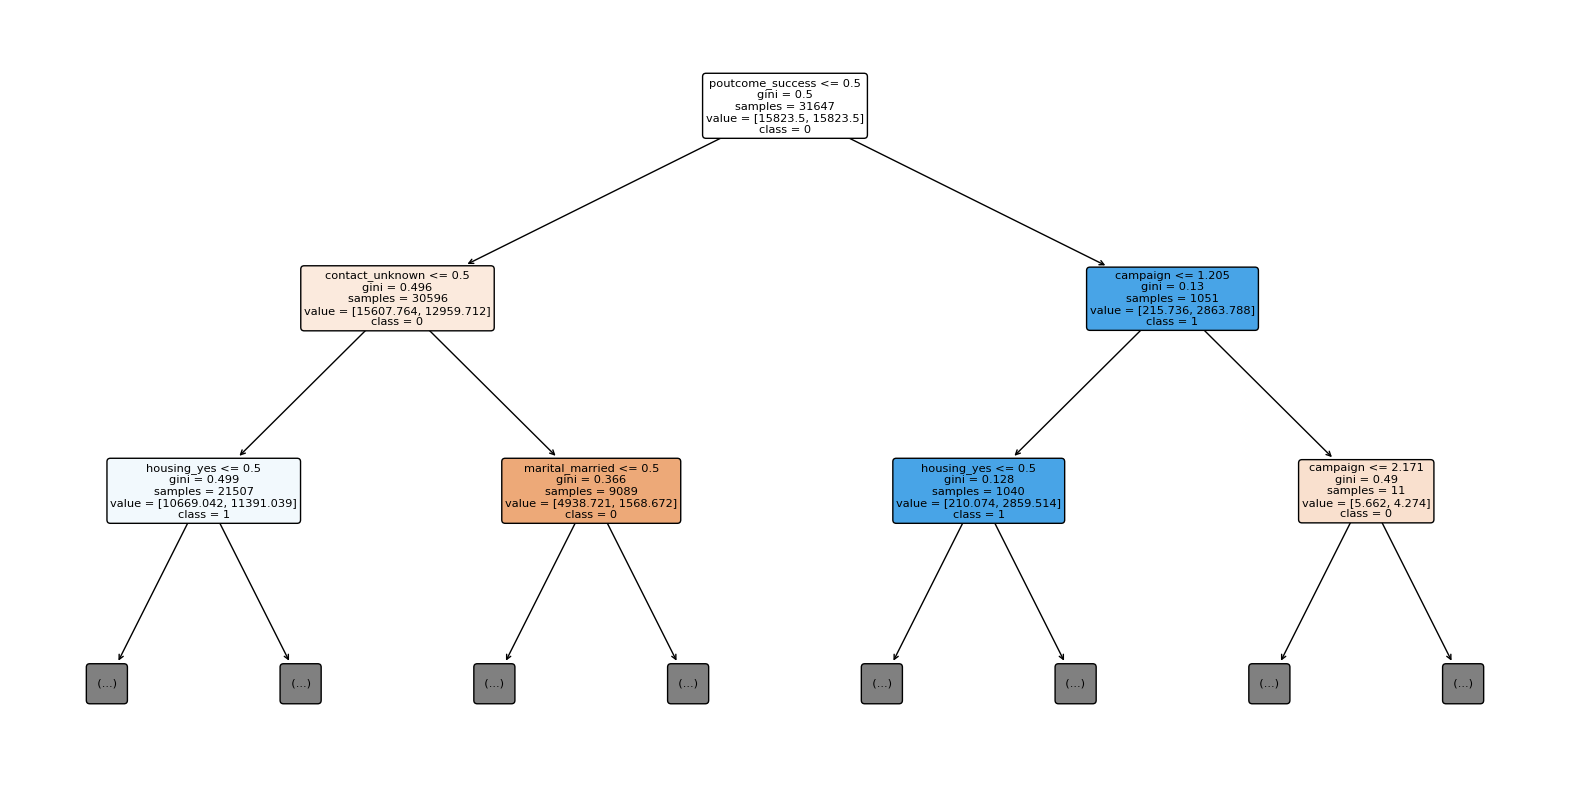

In [51]:


from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model_DT_Bal,
    max_depth=2,            # show only top levels (change to 4 or 5 if you want)
    filled=True,
    rounded=True,
    feature_names=X_train_final.columns,
    class_names=["0", "1"]
)
plt.show()


##### Interpreation & Explanation - Decision Tree(Balanced)
- **Why threshold sweep didn’t change anything ?**
  - It is clear that across thresholds from 0.10 to 0.50, all reported metrics (accuracy, recall, precision, etc.) remain identical at every threshold.

  - That happened because the tree’s predicted probabilities were only 0 or 1 (no values like 0.3, 0.7, etc.).
  - In a single Decision Tree, probabilities come from the leaf node where the sample ends up.
  - My tree’s leaves are basically pure (mostly one class), so each sample gets a probability of 100% “no” or 100% “yes.”

  - Because of that, changing the threshold doesn’t change predictions (unless the threshold is exactly 0 or 1).

  - I used the default threshold of 0.5 instead of testing multiple probability cutoffs. Meaning: predict class 1 if probability ≥ 0.5, else class 0.
- **Results of the final metrics at threshhold = 0.5**:

  - **Accuracy (0.844)** : 84.4 % of ll  predictions(yes+no) are correct. 

  - **Recall(0.307)** : The tree correctly cateched about 30.7% of all true “yes” (positive) cases.

  - **Precision (0.325)** : Of all the samples predicted “yes,” about 32.5% are truly positive.

  - **F1 (0.316)**: It shows the balance of precision and recall. Since both precision (0.325) and recall (0.307) are low, F1 is also low.

  - **Predicted Positive Rate (0.111)**: The model predicted “yes” for 11.1% of validation cases. It’s not predicting “yes” very often.



##### D3- Decision Tree-  Confusion Matrix (Balanced, validation)
- Confusion matrix for the Decision Tree using balanced weights on the validation data.
- It shows us how balancing the classes changes our correct and incorrect predictions.


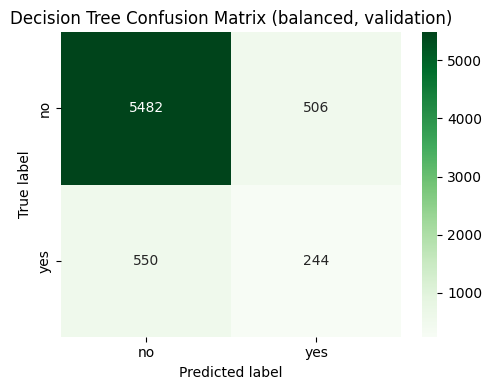

In [52]:
import numpy as np

probs = globals().get("probs_val_DT_BAL")
thresh = globals().get("THRESH_DT_BAL")
y_val_b = np.array(Y_val, dtype=int)

if probs is None or thresh is None:
    raise ValueError("Balanced Decision Tree probabilities or threshold not found. Check previous cells!!!")

y_pred = (probs >= thresh).astype(int)

# Set up confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ["no", "yes"]

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Decision Tree Confusion Matrix (balanced, validation)")
plt.tight_layout()
plt.show()

##### Decision Tree Classifier – Quick Comparison (Unweighted vs Balanced)


In [53]:
probs_a_unw = globals().get("probs_val_DT_UNW")
probs_b_bal = globals().get("probs_val_DT_BAL")
y_val_b = np.array(Y_val, dtype=int)

threshold_a_unw = globals().get("THRESH_DT_UNW")
threshold_b_bal = globals().get("THRESH_DT_BAL")

y_val_b = np.array(Y_val, dtype=int)

def evaluate_model(probs, thresh):
    if probs is None:
        raise ValueError("probabilities array is None — check globals() name.")
    if thresh is None:
        raise ValueError("threshold is None — check globals() name.")
    y_pred = (probs >= thresh).astype(int)
    return {
        "threshold": float(thresh),
        "recall":    recall_score(y_val_b, y_pred, zero_division=0),
        "precision": precision_score(y_val_b, y_pred, zero_division=0),
        "f1":        f1_score(y_val_b, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_val_b, y_pred),
        "pred_pos_rate": float(y_pred.mean())
    }

final = [
    {"model": "Decision Tree (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)},
    {"model": "Decision Tree (balanced)",   **evaluate_model(probs_b_bal, threshold_b_bal)}
]

results = pd.DataFrame(final, columns=["model","threshold","recall","precision","f1","accuracy","pred_pos_rate"]).round(3)
display(results)

,model,threshold,recall,precision,f1,accuracy,pred_pos_rate
0,Decision Tree (unweighted),0.1,0.331,0.313,0.322,0.836,0.124
1,Decision Tree (balanced),0.1,0.307,0.325,0.316,0.844,0.111


##### E1- Random Forest (Baseline, Unweighted) - Fit + cache Validation probabilities
- Train a baseline Random Forest model without class weights.

- Predict and save validation probabilities for later threshold tuning.

- Report accuracy, precision, recall, and F1 on the validation set, and plot the confusion matrix.



In [54]:
Model_Name = "Random Forest- Unweighted"
Model_Tag = "RF_UNW"

# Define the model
model_rf_unw = RandomForestClassifier(random_state=42,n_estimators=100) # Number of trees in the forest

# Safety Checks
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

# Fit the model
model_rf_unw.fit(X_train_final, Y_train)

# Cache validation probabilities
probs_val = model_rf_unw.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_rf_unw  
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")
  


[OK] 'Random Forest- Unweighted' fitted — cached as probs_val_RF_UNW.


##### E2 - Random Forest (Unweighted): Threshold Sweep, Selection, and Final Lock

In [55]:
Model_Tag = "RF_UNW"

probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,    
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor    
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.694338,0.741814,0.239723,0.362350,0.362283
1,0.11,0.720731,0.722922,0.255338,0.377383,0.331466
2,0.12,0.742111,0.709068,0.270543,0.391652,0.306842
3,0.13,0.761427,0.692695,0.285863,0.404709,0.283692
4,0.14,0.776025,0.683879,0.299834,0.416891,0.267030
5,0.15,0.788263,0.664987,0.310954,0.423756,0.250369
6,0.16,0.798142,0.638539,0.319069,0.425514,0.234297
7,0.17,0.805220,0.619647,0.325612,0.426898,0.222796
8,0.18,0.814067,0.607053,0.336827,0.433258,0.211000
9,0.19,0.820849,0.594458,0.345788,0.437239,0.201268



[LOCKED] THRESH_RF_UNW = 0.15


##### E3 - Random Forest Confusion Matrix (Unweighted, Validation)

 - Displays the confusion matrix for the unweighted Random Foreast on the validation set.

- Makes TP, FP, TN, and FN easy to compare, not just overall accuracy.

- Focus on recall for the minority class (“yes”) to see how many subscribers are being missed (FN).

- Use these results to support threshold choice and guide the next model improvements.

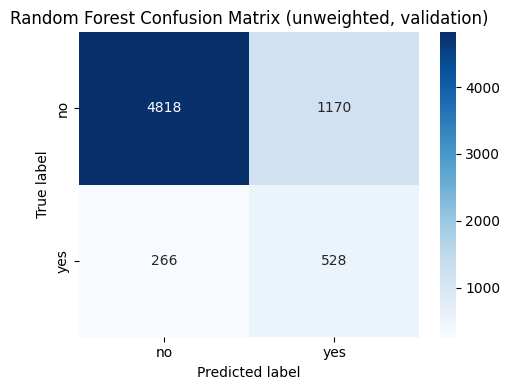

In [56]:
Model_Tag = "RF_UNW"

probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")    
plt.title("Random Forest Confusion Matrix (unweighted, validation)")
plt.tight_layout()
plt.show()  

##### F1 - Random Forest (Baseline, Balanced) - Fit + Cache Validation Probabilities


In [57]:
Model_Name = 'Random Forest- Balanced'
Model_Tag = 'RF_BAL'

model_rf_bal = RandomForestClassifier(n_estimators=100, # Number of trees in the forest
                                     random_state=42,
                                     class_weight='balanced'  
                                    )
# Safety Checks
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch." 

model_rf_bal.fit(X_train_final, Y_train)

probs_val = model_rf_bal.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val 
globals()[f"model_{Model_Tag}"] = model_rf_bal
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")

[OK] 'Random Forest- Balanced' fitted — cached as probs_val_RF_BAL.


####  Random Forest (Balanced): Threshold
**F2- Threshold Sweep/Lock Best Threshold**
- No hyperparameter tuning yet; simply train the model using balanced class weights.

- Evaluate on the validation set and save predicted probabilities for later threshold tuning.

- Compute key metrics: accuracy, precision, recall, and F1-score.

- Plot the confusion matrix to visualize classification errors.


In [58]:
Model_Tag = "RF_BAL"

probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)    
threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])  
metrics_df = pd.DataFrame(
    metrics,
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df) 
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
# 2) if none meet the rule, use best F1
# pick best rows from the metrics_df (not the main df)
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]   
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")    
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")        

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.712474,0.750630,0.253833,0.379376,0.346211
1,0.11,0.732970,0.721662,0.264910,0.387555,0.318932
2,0.12,0.755972,0.700252,0.281804,0.401879,0.290917
3,0.13,0.771454,0.678841,0.293893,0.410198,0.270422
4,0.14,0.785314,0.663728,0.307110,0.419920,0.253023
5,0.15,0.796520,0.643577,0.317786,0.425479,0.237098
6,0.16,0.809053,0.624685,0.332217,0.433756,0.220142
7,0.17,0.819375,0.608312,0.345741,0.440895,0.205986
8,0.18,0.824978,0.593199,0.352809,0.442461,0.196845
9,0.19,0.831908,0.575567,0.362698,0.444985,0.185786



[LOCKED] THRESH_RF_BAL = 0.14


##### F3 - Random Forest Confusion Matrix (Balanced, Validation)

 - Displays the confusion matrix for the weighted Random Foreast on the validation set.

- Makes TP, FP, TN, and FN easy to compare, not just overall accuracy.

- Focus on recall for the minority class (“yes”) to see how many subscribers are being missed (FN).

- Use these results to support threshold choice and guide the next model improvements

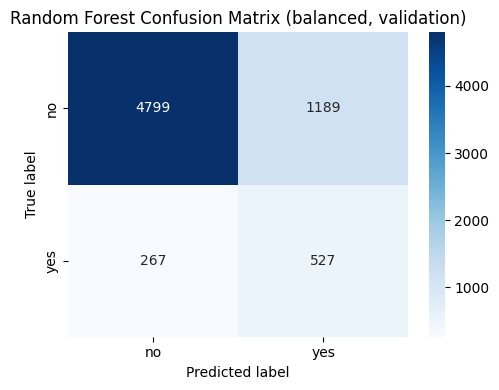

In [59]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]           

y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)     
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest Confusion Matrix (balanced, validation)")
plt.tight_layout()
plt.show()


##### Random Forest – Quick Comparison (Unweighted vs Balanced)


In [60]:
probs_a_unw = globals().get("probs_val_RF_UNW")
probs_b_bal = globals().get("probs_val_RF_BAL")

y_val_b = np.array(Y_val, dtype=int)
threshold_a_unw = globals().get("THRESH_RF_UNW")
threshold_b_bal = globals().get("THRESH_RF_BAL")

def evaluate_model(probs, thresh):
    
    y_pred = (probs >= thresh).astype(int)
    return {
        "threshold": float(thresh),
        "recall":    recall_score(y_val_b, y_pred, zero_division=0),
        "precision": precision_score(y_val_b, y_pred, zero_division=0),
        "f1":        f1_score(y_val_b, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_val_b, y_pred),
        "pred_pos_rate": float(y_pred.mean())
    }

final = [
    {"model": "Random Forest (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)},
    {"model": "Random Forest (balanced)",   **evaluate_model(probs_b_bal, threshold_b_bal)}
]
results = pd.DataFrame(final, columns=["model","threshold","recall","precision","f1","accuracy","pred_pos_rate"]).round(3)
display(results)

,model,threshold,recall,precision,f1,accuracy,pred_pos_rate
0,Random Forest (unweighted),0.15,0.665,0.311,0.424,0.788,0.250
1,Random Forest (balanced),0.14,0.664,0.307,0.420,0.785,0.253


##### Summary Table: Unweighted vs. Balanced Models for Logistic Regression, Decision Tree, and Random Forest

In [61]:

def final_evaluation(model,X_train,Y_train,X_val,Y_val,Model_Name):

    # Train 
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(Y_train, y_pred_train)
    prec_train = precision_score(Y_train, y_pred_train, average='weighted', zero_division=0)
    rec_train = recall_score(Y_train, y_pred_train, average='weighted', zero_division=0)
    f1_train = f1_score(Y_train, y_pred_train, average='weighted', zero_division=0)

    # Validation
    y_pred_val = model.predict(X_val)
    acc_val = accuracy_score(Y_val, y_pred_val)
    prec_val = precision_score(Y_val, y_pred_val, average='weighted', zero_division=0)
    rec_val = recall_score(Y_val, y_pred_val, average='weighted', zero_division=0)
    f1_val = f1_score(Y_val, y_pred_val, average='weighted', zero_division=0)

    # table
    return pd.DataFrame([
        [Model_Name, 'train', round(acc_train,3), round(prec_train,3), round(rec_train,3), round(f1_train,3)],
        [Model_Name, 'val', round(acc_val,3), round(prec_val,3), round(rec_val,3), round(f1_val,3)]
    ], columns=["Model","Set","Accuracy","Precision_w","Recall_w","F1_w"])

model_lr_unw = globals()["model_LR_UNW"]
model_dt_unw = globals()["model_DT_UNW"]
model_rf_unw = globals()["model_RF_UNW"]

df_LR = final_evaluation(model_lr_unw, X_train_final, Y_train, X_val_final, Y_val, "Logestic Reg")
df_DT = final_evaluation(model_dt_unw, X_train_final, Y_train, X_val_final, Y_val, "Decision Tree")
df_RF = final_evaluation(model_rf_unw, X_train_final, Y_train, X_val_final, Y_val, "Random Forest")

# Combine
df_baselines = pd.concat([df_LR, df_DT, df_RF], ignore_index=True)
display(df_baselines)


,Model,Set,Accuracy,Precision_w,Recall_w,F1_w
0,Logestic Reg,train,0.892,0.869,0.892,0.863
1,Logestic Reg,val,0.893,0.873,0.893,0.865
2,Decision Tree,train,1.000,1.000,1.000,1.000
3,Decision Tree,val,0.836,0.841,0.836,0.839
4,Random Forest,train,1.000,1.000,1.000,1.000
5,Random Forest,val,0.895,0.876,0.895,0.875


##### G1 - SVC (Unweighted) Train + Validation Probabilities
- Train the unweighted SVC model on the training data and store validation probabilities for later threshold tuning.

- Use default hyperparameters to establish a baseline.

- Evaluate the initial validation performance.

- Plot the confusion matrix.



In [62]:
from sklearn.svm import SVC

Model_Name = "SVC (unweighted)"
Model_Tag = "SVC_UNW"   

# Define the model
model_svc_unw = SVC(
    probability=True,   # enable probability estimates
    random_state=42     # makes results reproducible
)
# Safety Checks
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."     

# Fit the model
model_svc_unw.fit(X_train_final, Y_train)
# Cache validation probabilities
probs_val = model_svc_unw.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_svc_unw
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")

[OK] 'SVC (unweighted)' fitted — cached as probs_val_SVC_UNW.


##### G2- SVC(Unweighted): Threshold , Selection, and Final 
- Sweep across multiple thresholds using the cached validation probabilities.

- Select the best threshold based on the recall–precision trade-off.

- Fix this threshold and use the model as a reference for comparison with later models.

In [63]:
Model_Tag = "SVC_UNW"

probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])

metrics_df = pd.DataFrame(
    metrics,            
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:       
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None 
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.871572,0.469773,0.453220,0.461348,0.121351
1,0.11,0.885137,0.379093,0.512777,0.435916,0.086553
2,0.12,0.890298,0.346348,0.550000,0.425039,0.073725
3,0.13,0.892657,0.299748,0.580488,0.395349,0.060454
4,0.14,0.893542,0.279597,0.596774,0.380789,0.054851
5,0.15,0.894279,0.268262,0.610315,0.372703,0.051460
6,0.16,0.894426,0.260705,0.616071,0.366372,0.049543
7,0.17,0.894426,0.254408,0.619632,0.360714,0.048068
8,0.18,0.894574,0.250630,0.623824,0.357592,0.047036
9,0.19,0.894574,0.246851,0.626198,0.354110,0.046152



[LOCKED] THRESH_SVC_UNW = 0.10


##### G3- SVC (Unweighted) Confusion Matrix — Validation
- Confusion matrix for the unweighted SVC model evaluated on the validation set.

- Clearly displays true positives, false positives, true negatives, and false negatives.

- Provides insight into model behavior beyond overall accuracy.

- Recall is a critical metric here, particularly for the minority “yes” class.

- Helps detect whether the model is missing too many actual “yes” cases (high false negatives).

- This confusion matrix informs threshold tuning and guides further model refinement.

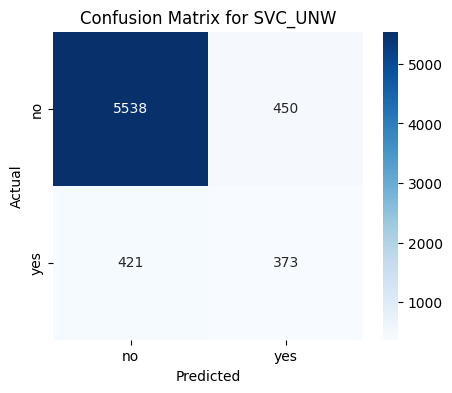

In [64]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)     
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix for {Model_Tag}")
plt.show()

##### H1- SVC (Balanced) Train + Cache Validation Probabilities
- Instantiate the SVC model using class_weight="balanced".

- Evaluate on the validation set and compare results against the unweighted SVC baseline.

- Plot the confusion matrix to visualize differences in errors (especially FN for the “yes” class).


In [65]:
from sklearn.svm import SVC


Model_Name = "SVC (balanced)"
Model_Tag = "SVC_BAL"


model_svc_bal = SVC(
    probability=True,   
    random_state=42,    
    class_weight='balanced'  
)

# Safety Checks
assert 'X_train_final' in dir() and 'X_val_final' in dir(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

model_svc_bal.fit(X_train_final, Y_train)

probs_val = model_svc_bal.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_svc_bal
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")

[OK] 'SVC (balanced)' fitted — cached as probs_val_SVC_BAL.


##### H2- SVC(Balanced): Threshold , Selection, and Final 

In [66]:
Model_Tag = "SVC_BAL"   
probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,    
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")
    

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.769242,0.688917,0.293298,0.411433,0.274993
1,0.11,0.786494,0.673804,0.310325,0.424940,0.254202
2,0.12,0.802123,0.661209,0.328536,0.438963,0.235624
3,0.13,0.813624,0.644836,0.342704,0.447552,0.220289
4,0.14,0.823356,0.636020,0.357143,0.457428,0.208493
5,0.15,0.828959,0.613350,0.363433,0.456420,0.197582
6,0.16,0.835447,0.604534,0.374415,0.462428,0.189030
7,0.17,0.841935,0.589421,0.385502,0.466135,0.179003
8,0.18,0.846948,0.583123,0.395726,0.471487,0.172515
9,0.19,0.849160,0.565491,0.398403,0.467465,0.166175



[LOCKED] THRESH_SVC_BAL = 0.11


##### H3 - SVC (Balanced) Confusion Matrix — Validation

- Confusion matrix for the balanced SVC model evaluated on the validation set.

- Shows how using class weights changes the counts of true/false positives and true/false negatives.

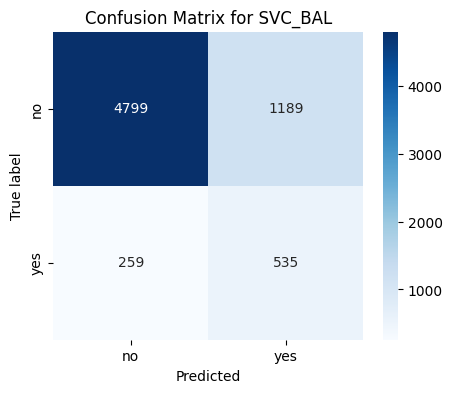

In [67]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)    
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)  
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True label")
plt.title(f"Confusion Matrix for {Model_Tag}")
plt.show()


##### SVC – Quick Comparison (Unweighted vs Balanced)


In [68]:
probs_a_unw = globals().get("probs_val_SVC_UNW")
probs_b_bal = globals().get("probs_val_SVC_BAL")

y_val_b = np.array(Y_val, dtype=int)
threshold_a_unw = globals().get("THRESH_SVC_UNW")
threshold_b_bal = globals().get("THRESH_SVC_BAL")

def evaluate_model(probs, thresh):
    
    y_pred = (probs >= thresh).astype(int)
    return {
        "threshold": float(thresh),
        "recall":    recall_score(y_val_b, y_pred, zero_division=0),
        "precision": precision_score(y_val_b, y_pred, zero_division=0),
        "f1":        f1_score(y_val_b, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_val_b, y_pred),
        "pred_pos_rate": float(y_pred.mean())
    }
final = [
    {"model": "SVC (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)},
    {"model": "SVC (balanced)",   **evaluate_model(probs_b_bal, threshold_b_bal)}
]
results = pd.DataFrame(final, columns=["model","threshold","recall","precision","f1","accuracy","pred_pos_rate"]).round(3)
display(results)


,model,threshold,recall,precision,f1,accuracy,pred_pos_rate
0,SVC (unweighted),0.10,0.470,0.453,0.461,0.872,0.121
1,SVC (balanced),0.11,0.674,0.310,0.425,0.786,0.254


##### I1 - XGBoost (Unweighted) Train + Cache Validation Probabilities

- Train an unweighted XGBoost model on the training data and save validation probabilities for later threshold tuning.

- Use default hyperparameters to establish a baseline.

- Evaluate the initial performance on the validation set.

- Plot the confusion matrix.

- Record the main results and brief insights.

In [69]:
# safety check
assert 'X_train_final' in globals() and 'X_val_final' in globals(), " Run Preprocessing/split First."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

Model_Name = "XGBoost (Unweighted)"
Model_Tag = "XGB_UNW"

model_xgb_unw = XGBClassifier(
  
    eval_metric='logloss',
    random_state=42
)
model_xgb_unw.fit(X_train_final, Y_train)
probs_val = model_xgb_unw.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val     
globals()[f"model_{Model_Tag}"] = model_xgb_unw
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}")

[OK] 'XGBoost (Unweighted)' fitted — cached as probs_val_XGB_UNW


#### I2- XGBoost (Unweighted): Threshold Sweep, Selection, and Final Lock

- Sweep across a range of thresholds using the cached validation probabilities.

- hoose the best threshold based on the recall–precision trade-off.

- Fix the selected threshold and keep this model as a baseline for future comparisons.

- Summarize the final metrics and key notes.

In [70]:
Model_Tag = "XGB_UNW"
probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)
threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:

    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,    
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor    
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]  
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
    
if recall_first is not None:    
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")


,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.763197,0.687657,0.286765,0.404744,0.280743
1,0.11,0.783545,0.658690,0.304070,0.416070,0.253613
2,0.12,0.802566,0.638539,0.325208,0.430939,0.229873
3,0.13,0.819670,0.623426,0.348837,0.447357,0.209230
4,0.14,0.832793,0.608312,0.369832,0.460000,0.192569
5,0.15,0.838396,0.584383,0.377236,0.458498,0.181362
6,0.16,0.844441,0.556675,0.386026,0.455905,0.168829
7,0.17,0.852551,0.547859,0.404275,0.465241,0.158655
8,0.18,0.857417,0.528967,0.414610,0.464859,0.149366
9,0.19,0.864199,0.517632,0.433087,0.471601,0.139929



[LOCKED] THRESH_XGB_UNW = 0.11


##### I3- XGBoost (Unweighted) Confusion Matrix — Validation
- Confusion matrix for the unweighted XGBoost model evaluated on the validation set.

- Clearly shows true positives, false positives, true negatives, and false negatives
- Gives a clearer picture of model behavior beyond overall accuracy.

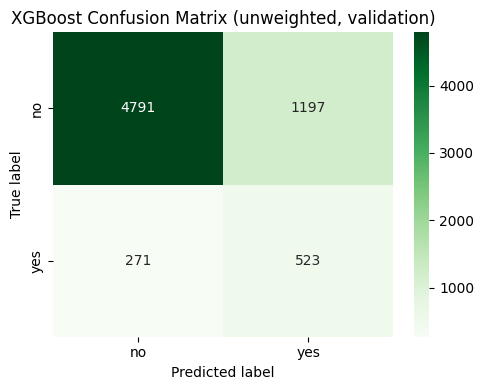

In [71]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))   
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.title("XGBoost Confusion Matrix (unweighted, validation)")
plt.tight_layout()
plt.show()  


##### M1 - XGBoost (Balanced) Train + Cache Validation Probabilities
- Repeat the same workflow, but apply class weighting to better handle the class imbalance.

- Use the scale_pos_weight parameter when initializing the XGBoost model.

- Evaluate on the validation set and compare results with the unweighted version.

- Plot the confusion matrix to visualize changes in TP/FP/TN/FN.

- Summarize the results and main insights.

In [72]:
Model_Name = "XGBoost (Balanced)"
Model_Tag = "XGB_BAL"

# Calculate class ratio on training set
neative_count = sum(Y_train == 0)
positive_count = sum(Y_train == 1)
scale = neative_count / positive_count

print(f"Class ratio (neg/pos) in training set for {Model_Name}: {scale:.2f}")    

model_xgb_bal = XGBClassifier(
                              scale_pos_weight=scale,   
                                eval_metric='logloss',      
                                random_state=42
                             )

#safety check

assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

# Fit model
model_xgb_bal.fit(X_train_final, Y_train)

probs_val = model_xgb_bal.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val     
globals()[f"model_{Model_Tag}"] = model_xgb_bal
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}")


Class ratio (neg/pos) in training set for XGBoost (Balanced): 7.55
[OK] 'XGBoost (Balanced)' fitted — cached as probs_val_XGB_BAL


##### M2 - XGBoost (Balanced) — Threshold Sweep and Lock Best Threshold

- Sweep across a range of thresholds using the cached validation probabilities.

- Select the best threshold based on the recall–precision trade-off.

- Fix this chosen threshold and keep the model for comparison with future models.

- Document the final threshold, metrics, and key takeaways.

In [73]:

Model_Tag = "XGB_BAL"
probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)
threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,    
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")


,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.277057,0.952141,0.134496,0.235698,0.828812
1,0.11,0.297847,0.942065,0.136896,0.239054,0.805662
2,0.12,0.317605,0.933249,0.139391,0.242553,0.783840
3,0.13,0.340902,0.926952,0.142968,0.247728,0.759068
4,0.14,0.358301,0.914358,0.144910,0.250172,0.738720
5,0.15,0.377765,0.911839,0.148543,0.255469,0.718667
6,0.16,0.399440,0.905542,0.152427,0.260933,0.695518
7,0.17,0.418313,0.899244,0.155929,0.265773,0.675170
8,0.18,0.440725,0.887909,0.159900,0.270998,0.650103
9,0.19,0.456650,0.869018,0.161555,0.272458,0.629755



[LOCKED] THRESH_XGB_BAL = 0.45


##### M3 - XGBoost (Balanced) - Confusion Matrix (Validation)

- Confusion matrix for the balanced XGBoost model on the validation set.

- Shows how class weighting changes TP/FP/TN/FN compared to the unweighted model.

- Typically increases TP and reduces FN (better recall for the minority “yes” class).

- Useful for deciding the next threshold and model improvements.

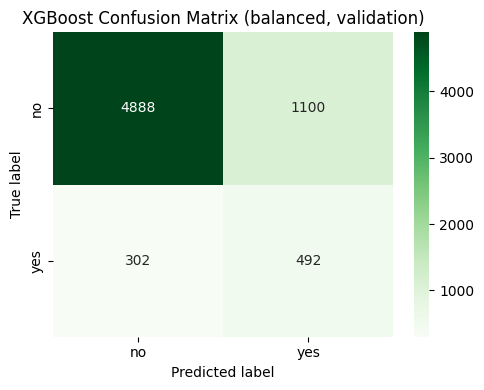

In [74]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']

# Plot confusion matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("XGBoost Confusion Matrix (balanced, validation)")
plt.tight_layout()
plt.show()

##### XGBoost – Quick Comparison (Unweighted vs Balanced)




In [75]:
probs_a_unw = globals().get("probs_val_XGB_UNW")
probs_b_bal = globals().get("probs_val_XGB_BAL")
y_val_b = np.array(Y_val, dtype=int)
threshold_a_unw = globals().get("THRESH_XGB_UNW")
threshold_b_bal = globals().get("THRESH_XGB_BAL")

def evaluate_model(probs, thresh):
    
    y_pred = (probs >= thresh).astype(int)
    return {
        "threshold": float(thresh),
        "recall":    recall_score(y_val_b, y_pred, zero_division=0),
        "precision": precision_score(y_val_b, y_pred, zero_division=0),
        "f1":        f1_score(y_val_b, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_val_b, y_pred),
        "pred_pos_rate": float(y_pred.mean())
    }
final = [
    {"model": "XGBoost (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)},
    {"model": "XGBoost (balanced)",   **evaluate_model(probs_b_bal, threshold_b_bal)}
]
results = pd.DataFrame(final, columns=["model","threshold","recall","precision","f1","accuracy","pred_pos_rate"]).round(3)
display(results)


,model,threshold,recall,precision,f1,accuracy,pred_pos_rate
0,XGBoost (unweighted),0.11,0.659,0.304,0.416,0.784,0.254
1,XGBoost (balanced),0.45,0.620,0.309,0.412,0.793,0.235


##### J1 - LightGBM (Unweighted) Train + Cache Validation Probabilities
-  Train an unweighted LightGBM model on the training data and save validation probabilities for later threshold tuning.
-  Consider scale_pos_weight to handle class imbalanc.

In [76]:
Model_Name = "LightGBM (Unweighted)"
Model_Tag = "LGBM_UNW"

model_lgbm_unw = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    scale_pos_weight=1
)

#safety check
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

# Fit model
model_lgbm_unw.fit(X_train_final, Y_train)
probs_val = model_lgbm_unw.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_lgbm_unw
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}")



[LightGBM] [Info] Number of positive: 3702, number of negative: 27945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 31647, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116978 -> initscore=-2.021365
[LightGBM] [Info] Start training from score -2.021365
[OK] 'LightGBM (Unweighted)' fitted — cached as probs_val_LGBM_UNW


##### J2 - Results of (Unweighted) Validation Results
- **Number of positive: 3702, number of negative: 27945**
  - In the training data : 3702 rows are “yes” (class 1) , 27945 rows are “no” (class 0). So “yes” is the minority class (about 11.7% of the data).

- **“Bins” (how LightGBM handles numbers)**
  - Total bins 777 : 
    - LightGBM doesn’t always split using exact raw values.

    - It groups numeric values into bins (like buckets) to train faster.

- **Dataset size and features**
  - The training set has 31,647 rows.

  - LightGBM used 50 features (columns) to learn patterns.

- **Starting baseline probability**
  - pavg (pavg=0.116978) is the average of your positive class (yes rate).

  - So LightGBM sees that about 11.7% of cases are “yes”.
  - Start training from initscore=-2.021365. 



##### J3- LightGBM (Unweighted) — Threshold Sweep, Selection, and Lock
- Sweep across multiple thresholds using the cached validation probabilities.

- Choose the best threshold based on the recall–precision trade-off.

- Fix the selected threshold and retain this model for comparison with future models.

- Document the final metrics and key notes.


In [77]:

Model_Tag = "LGBM_UNW"

probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df) 
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor        
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")    
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")


,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.768357,0.705290,0.295203,0.416202,0.279711
1,0.11,0.792244,0.678841,0.318370,0.433454,0.249631
2,0.12,0.812887,0.653652,0.343027,0.449935,0.223091
3,0.13,0.827632,0.634761,0.364425,0.463023,0.203922
4,0.14,0.839723,0.610831,0.384006,0.471561,0.186228
5,0.15,0.848275,0.603275,0.401509,0.482134,0.175907
6,0.16,0.852993,0.593199,0.411354,0.485817,0.168829
7,0.17,0.859334,0.578086,0.425788,0.490385,0.158950
8,0.18,0.865231,0.568010,0.441292,0.496696,0.150693
9,0.19,0.869065,0.560453,0.452236,0.500562,0.145090



[LOCKED] THRESH_LGBM_UNW = 0.11


##### J4 - LightGBM (Unweighted)- Confusion Matrix (Validation)
- Confusion matrix for the unweighted LightGBM model on the validation set.

- Displays TP, FP, TN, and FN to explain performance beyond accuracy.

- Recall is especially important for the minority “yes” class and highlights missed positives (high FN).

- Use this to support threshold tuning and guide next model improvements.

- Document the key results.

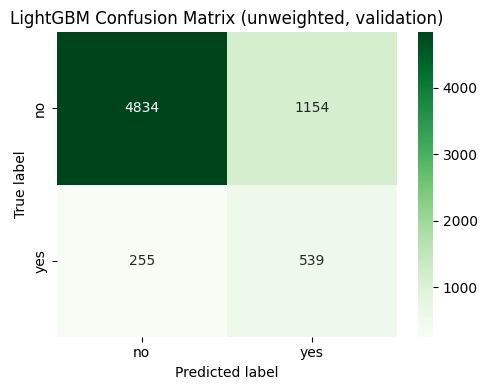

In [78]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)  

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("LightGBM Confusion Matrix (unweighted, validation)")
plt.tight_layout()  
plt.show()

##### K1 - LightGBM (Balanced)- Train + Cache Validation Probabilities
- Repeat the same workflow, but apply class weighting to handle class imbalance.

- Set scale_pos_weight when creating the LightGBM model.

- Evaluate on the validation set and compare results with the unweighted version.

- Document the key metrics and main observations.

In [79]:
Model_Name = "LightGBM (balanced)"
Model_Tag = "LGBM_BAL"

negative_count = sum(Y_train == 0)
positive_count = sum(Y_train == 1)
scale = negative_count / positive_count
print(f"Class ratio (neg/pos) in training set for {Model_Name}: {scale:.2f}")

#Safety check
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

model_lgbm_bal = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    scale_pos_weight=scale,
    verbose=-1
)

# Fit model
model_lgbm_bal.fit(X_train_final, Y_train)
probs_val = model_lgbm_bal.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_lgbm_bal
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}")

Class ratio (neg/pos) in training set for LightGBM (balanced): 7.55
[OK] 'LightGBM (balanced)' fitted — cached as probs_val_LGBM_BAL


##### K3- LightGBM (Balanced) — Threshold Sweep, Selection, and Lock


In [80]:
Model_Tag = "LGBM_BAL"

probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,    
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")
    

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.170451,0.991184,0.122854,0.218611,0.944559
1,0.11,0.182100,0.987406,0.124031,0.220379,0.932026
2,0.12,0.195223,0.983627,0.125442,0.222507,0.918018
3,0.13,0.212917,0.977330,0.127297,0.225254,0.898850
4,0.14,0.230758,0.967254,0.128881,0.227454,0.878649
5,0.15,0.251401,0.962217,0.131475,0.231340,0.856827
6,0.16,0.273666,0.954660,0.134207,0.235331,0.832793
7,0.17,0.297110,0.948363,0.137434,0.240077,0.807874
8,0.18,0.318785,0.939547,0.140278,0.244110,0.784134
9,0.19,0.341787,0.935768,0.144104,0.249748,0.760248



[LOCKED] THRESH_LGBM_BAL = 0.45


 #### K4- LightGBM (Balanced) - Confusion Matrix (Validation)

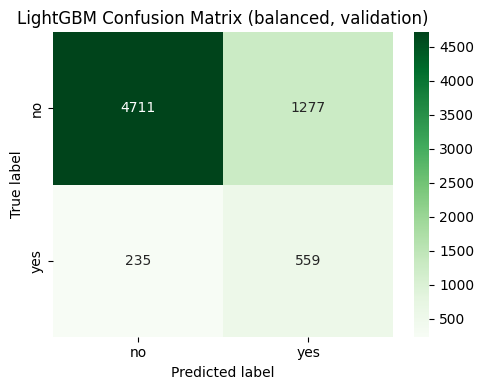

In [81]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")   
plt.ylabel("True label")
plt.title("LightGBM Confusion Matrix (balanced, validation)")
plt.tight_layout()
plt.show()

##### LightGBM – Quick Comparison (Unweighted vs Balanced)

In [82]:
probs_a_unw = globals().get("probs_val_LGBM_UNW")
probs_b_bal = globals().get("probs_val_LGBM_BAL")   
y_val_b = np.array(Y_val, dtype=int)
threshold_a_unw = globals().get("THRESH_LGBM_UNW")
threshold_b_bal = globals().get("THRESH_LGBM_BAL")

def evaluate_model(probs, thresh):
    y_pred = (probs >= thresh).astype(int)
    return {
        "threshold": float(thresh),
        "recall":    recall_score(y_val_b, y_pred, zero_division=0),
        "precision": precision_score(y_val_b, y_pred, zero_division=0),
        "f1":        f1_score(y_val_b, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_val_b, y_pred),
        "pred_pos_rate": float(y_pred.mean())
    }

# Check if the balanced model data exists
if probs_b_bal is None or threshold_b_bal is None:
    print("Warning: LGBM_BAL probabilities or threshold not found. Please run cells 50 and 53 first.")
    print("Displaying unweighted model results only.")
    
    final = [
        {"model": "LightGBM (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)}
    ]
else:
    final = [
        {"model": "LightGBM (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)},
        {"model": "LightGBM (balanced)",   **evaluate_model(probs_b_bal, threshold_b_bal)}
    ]

results = pd.DataFrame(final, columns=["model","threshold","recall","precision","f1","accuracy","pred_pos_rate"]).round(3)
display(results)

,model,threshold,recall,precision,f1,accuracy,pred_pos_rate
0,LightGBM (unweighted),0.11,0.679,0.318,0.433,0.792,0.250
1,LightGBM (balanced),0.45,0.704,0.304,0.425,0.777,0.271


##### L1 - CatBoost (Unweighted) -  Train + Cache Validation Probabilities

In [83]:
Model_Name = "CatBoost (Unweighted)"
Model_Tag = "CATB_UNW"


# Create the CatBoostClassifier model
model_catb_unw = CatBoostClassifier(
    random_state=42,
    verbose=0
)

# Safety Checks
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch." 

# Fit the model
model_catb_unw.fit(X_train_final, Y_train)
# Cache validation probabilities
probs_val = model_catb_unw.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_catb_unw
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")

[OK] 'CatBoost (Unweighted)' fitted — cached as probs_val_CATB_UNW.


##### L2 - CatBoost (Unweighted) - Threshold Sweep, Selection, and Lock

In [84]:
Model_Tag = "CATB_UNW"




probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)    


threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])

metrics_df = pd.DataFrame(
    metrics,            
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")
    

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.768800,0.697733,0.294368,0.414051,0.277499
1,0.11,0.795783,0.680101,0.323160,0.438134,0.246387
2,0.12,0.818932,0.661209,0.353774,0.460931,0.218815
3,0.13,0.832498,0.644836,0.374817,0.474074,0.201416
4,0.14,0.842672,0.628463,0.392604,0.483293,0.187408
5,0.15,0.850634,0.610831,0.407906,0.489158,0.175317
6,0.16,0.856385,0.583123,0.418626,0.487368,0.163079
7,0.17,0.864199,0.575567,0.439001,0.498093,0.153495
8,0.18,0.868033,0.568010,0.449651,0.501948,0.147891
9,0.19,0.871424,0.559194,0.459627,0.504545,0.142436



[LOCKED] THRESH_CATB_UNW = 0.11


##### L3 -CatBoost (Unweighted) -  Confusion Matrix (Validation)

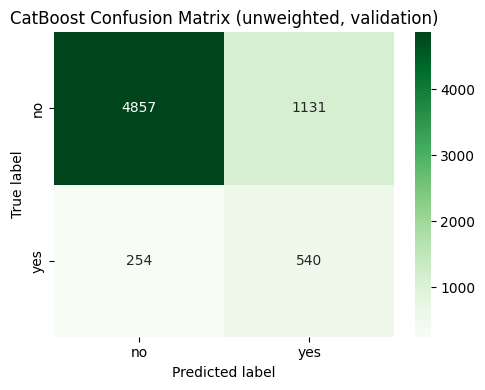

In [85]:
probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("CatBoost Confusion Matrix (unweighted, validation)")
plt.tight_layout()          
plt.show()

##### M1- CatBoost (Balanced) -  Train + Cache Validation Probabilities

In [86]:
Model_Name = "CatBoost (Balanced)"
Model_Tag = "CATB_BAL"
# Create the CatBoostClassifier model with class weights
negative_count = sum(Y_train == 0)
positive_count = sum(Y_train == 1)
weight_0 = 1.0
weight_1 = negative_count / positive_count
print(f"Class weights for {Model_Name}: [0]: {weight_0:.2f}, [1]: {weight_1:.2f}")

model_catb_bal = CatBoostClassifier(
    n_estimators=100,
    random_state=42,
    class_weights=[weight_0, weight_1],
    verbose=0
)   

# Safety Checks
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."

# Fit the model
model_catb_bal.fit(X_train_final, Y_train)
# Cache validation probabilities
probs_val = model_catb_bal.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_catb_bal
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")

Class weights for CatBoost (Balanced): [0]: 1.00, [1]: 7.55
[OK] 'CatBoost (Balanced)' fitted — cached as probs_val_CATB_BAL.


##### M2 - CatBoost (Balanced) - Threshold Sweep, Selection, and Lock


In [87]:
Model_Tag = "CATB_BAL"
probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30
metrics = []

for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None

if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")        
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")


,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.242406,0.954660,0.129352,0.227833,0.864052
1,0.11,0.258773,0.950882,0.131464,0.230993,0.846800
2,0.12,0.276467,0.947103,0.133879,0.234597,0.828222
3,0.13,0.295046,0.942065,0.136422,0.238330,0.808464
4,0.14,0.311118,0.937028,0.138651,0.241558,0.791212
5,0.15,0.330139,0.928212,0.141107,0.244973,0.770127
6,0.16,0.350929,0.918136,0.143901,0.248805,0.746977
7,0.17,0.369213,0.908060,0.146366,0.252098,0.726334
8,0.18,0.388971,0.897985,0.149288,0.256014,0.704217
9,0.19,0.408876,0.889169,0.152583,0.260469,0.682247



[LOCKED] THRESH_CATB_BAL = 0.47


##### M3 - CatBoost (Balanced) - Confusion Matrix (Validation)

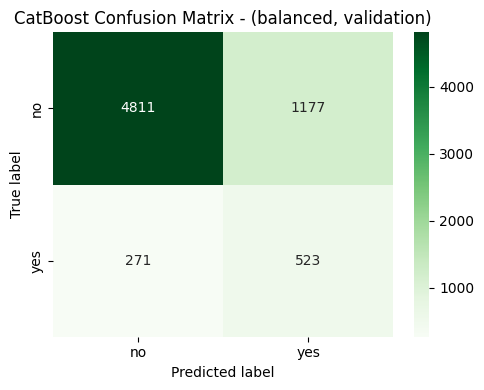

In [88]:

probs = globals()[f"probs_val_{Model_Tag}"]
thresh = globals()[f"THRESH_{Model_Tag.upper()}"]
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)
# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)  
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("CatBoost Confusion Matrix - (balanced, validation)")
plt.tight_layout()
plt.show()

##### CatBoost Quick Comparison - (Unweighted vs Balanced)



In [89]:
probs_a_unw = globals().get("probs_val_CATB_UNW")
probs_b_bal = globals().get("probs_val_CATB_BAL")
y_val_b = np.array(Y_val, dtype=int)
threshold_a_unw = globals().get("THRESH_CATB_UNW")
threshold_b_bal = globals().get("THRESH_CATB_BAL")
def evaluate_model(probs, thresh):
    
    y_pred = (probs >= thresh).astype(int)
    return {
        "threshold": float(thresh),
        "recall":    recall_score(y_val_b, y_pred, zero_division=0),
        "precision": precision_score(y_val_b, y_pred, zero_division=0),
        "f1":        f1_score(y_val_b, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_val_b, y_pred),
        "pred_pos_rate": float(y_pred.mean())
    }
final = [
    {"model": "CatBoost (unweighted)", **evaluate_model(probs_a_unw, threshold_a_unw)},
    {"model": "CatBoost (balanced)",   **evaluate_model(probs_b_bal, threshold_b_bal)}
]
results = pd.DataFrame(final, columns=["model","threshold","recall","precision","f1","accuracy","pred_pos_rate"]).round(3)
display(results)

,model,threshold,recall,precision,f1,accuracy,pred_pos_rate
0,CatBoost (unweighted),0.11,0.680,0.323,0.438,0.796,0.246
1,CatBoost (balanced),0.47,0.659,0.308,0.419,0.786,0.251


##### **All Models - Validation Metrics and Top-3 Recall Ranking**

- This table reports the key validation metrics for each model variant, including recall, precision, F1, accuracy, predicted positive rate, and the selected threshold.
- The three best models by recall are listed below as candidates for the next hyperparameter-tuning step.


In [90]:
# List of all models evaluated
all_models = [
    {"name": "Logistic Regression (unweighted)", "probs": "probs_val_LR_UNW", "thresh": "THRESH_LR_UNW"},
    {"name": "Logistic Regression (balanced)",   "probs": "probs_val_lr_bal", "thresh": "THRESH_LR_BAL"},
    {"name": "Decision Tree (unweighted)",       "probs": "probs_val_DT_UNW", "thresh": "THRESH_DT_UNW"},
    {"name": "Decision Tree (balanced)",         "probs": "probs_val_DT_BAL", "thresh": "THRESH_DT_BAL"},
    {"name": "Random Forest (unweighted)",       "probs": "probs_val_RF_UNW", "thresh": "THRESH_RF_UNW"},
    {"name": "Random Forest (balanced)",         "probs": "probs_val_RF_BAL", "thresh": "THRESH_RF_BAL"},
    {"name": "SVC (unweighted)",                 "probs": "probs_val_SVC_UNW","thresh": "THRESH_SVC_UNW"},
    {"name": "SVC (balanced)",                   "probs": "probs_val_SVC_BAL","thresh": "THRESH_SVC_BAL"},
    {"name": "XGBoost (unweighted)",             "probs": "probs_val_XGB_UNW","thresh": "THRESH_XGB_UNW"},
    {"name": "XGBoost (balanced)",               "probs": "probs_val_XGB_BAL","thresh": "THRESH_XGB_BAL"},
    {"name": "LightGBM (unweighted)",            "probs": "probs_val_LGBM_UNW","thresh": "THRESH_LGBM_UNW"},
    {"name": "LightGBM (balanced)",              "probs": "probs_val_LGBM_BAL","thresh": "THRESH_LGBM_BAL"},
    {"name": "CatBoost (unweighted)",            "probs": "probs_val_CATB_UNW","thresh": "THRESH_CATB_UNW"},
    {"name": "CatBoost (balanced)",              "probs": "probs_val_CATB_BAL","thresh": "THRESH_CATB_BAL"},
]

y_val_b = np.array(Y_val, dtype=int)
final_results = []

for model in all_models:
    probs = globals().get(model["probs"])
    thresh = globals().get(model["thresh"])
    if probs is not None and thresh is not None:
        y_pred = (probs >= thresh).astype(int)
        final_results.append({
            "Model": model["name"],
            "Threshold": float(thresh),
            "Recall": recall_score(y_val_b, y_pred, zero_division=0),
            "Precision": precision_score(y_val_b, y_pred, zero_division=0),
            "F1": f1_score(y_val_b, y_pred, zero_division=0),
            "Accuracy": accuracy_score(y_val_b, y_pred),
            "Predicted Positive Rate": float(y_pred.mean())
        })
results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)
display(results_df)

print("\n Top 3 Models by Recall - Before Hyperparameter Tuning:")
display(results_df.head(3))

,Model,Threshold,Recall,Precision,F1,Accuracy,Predicted Positive Rate
0,LightGBM (balanced),0.45,0.704030,0.304466,0.425095,0.777057,0.270717
1,CatBoost (unweighted),0.11,0.680101,0.323160,0.438134,0.795783,0.246387
2,LightGBM (unweighted),0.11,0.678841,0.318370,0.433454,0.792244,0.249631
3,SVC (balanced),0.11,0.673804,0.310325,0.424940,0.786494,0.254202
4,Random Forest (unweighted),0.15,0.664987,0.310954,0.423756,0.788263,0.250369
5,Random Forest (balanced),0.14,0.663728,0.307110,0.419920,0.785314,0.253023
6,XGBoost (unweighted),0.11,0.658690,0.304070,0.416070,0.783545,0.253613
7,CatBoost (balanced),0.47,0.658690,0.307647,0.419407,0.786494,0.250664
8,Logistic Regression (balanced),0.50,0.628463,0.269148,0.376888,0.756709,0.273371
9,XGBoost (balanced),0.45,0.619647,0.309045,0.412406,0.793276,0.234739



 Top 3 Models by Recall - Before Hyperparameter Tuning:


,Model,Threshold,Recall,Precision,F1,Accuracy,Predicted Positive Rate
0,LightGBM (balanced),0.45,0.704030,0.304466,0.425095,0.777057,0.270717
1,CatBoost (unweighted),0.11,0.680101,0.323160,0.438134,0.795783,0.246387
2,LightGBM (unweighted),0.11,0.678841,0.318370,0.433454,0.792244,0.249631


##### Top 3 Models for Hyperparameter Tuning: LightGBM (Balanced),CatBoost (Unweighted) and LightGBM (Unweighted).
These three models achieved the highest recall on the validation set and will be further refined through hyperparameter tuning.


In [91]:
#LightGBM hyperparameter tuning

is_balanced = True 
count_negative = sum(Y_train == 0)
count_positive = sum(Y_train == 1)
scale_pos_weight = count_negative / count_positive 

param_grid = {
    'n_estimators': [50, 100, 200], #number of trees
    'max_depth': [3, 5, 7,-1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63]
    }

lgbm = LGBMClassifier(
        random_state=42,    
        scale_pos_weight= scale if is_balanced else 1,
        verbose=-1

    )
grid_search = GridSearchCV(
    lgbm,
    param_grid,
    scoring='recall',   
    cv=5,
    n_jobs=-1,
    verbose=2)
grid_search.fit(X_train_final, Y_train)
print(f"Best hyperparameters: {grid_search.best_params_}")  
best_recall = grid_search.best_score_
print(f"Best cross-validated recall: {best_recall:.4f}")


probs_val = grid_search.best_estimator_.predict_proba(X_val_final)[:, 1]



Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}
Best cross-validated recall: 0.6343


In [92]:

display(grid_search.best_estimator_)
display(grid_search.best_index_)


LGBMClassifier(max_depth=3, n_estimators=200, num_leaves=15, random_state=42,
               scale_pos_weight=7.548622366288493, verbose=-1)

78

##### LightGBM (Balanced, Tuned) Fit + cache VAL probabilities

In [93]:
Model_Name = "LightGBM (balanced, tuned)"
Model_Tag = "LGBM_BAL_TUNED"


# Create the LightGBM model with tuned hyperparameters
negative_count = sum(Y_train == 0)
positive_count = sum(Y_train == 1)
scale = negative_count / positive_count
print(f"Class ratio (neg/pos) in training set for {Model_Name}: {scale:.2f}")

best_lghbm_bal = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    num_leaves=15,
    scale_pos_weight=scale,
    verbose=1
)

best_lghbm_bal.fit(X_train_final, Y_train)

#safety check
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[
0] == len(Y_val), "Shape mismatch."

probs_val = best_lghbm_bal.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = best_lghbm_bal
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}")


Class ratio (neg/pos) in training set for LightGBM (balanced, tuned): 7.55
[LightGBM] [Info] Number of positive: 3702, number of negative: 27945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 31647, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116978 -> initscore=-2.021365
[LightGBM] [Info] Start training from score -2.021365
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

##### LightGBM (Balanced, Tuned) - Threshold Sweep and Lock Best Threshold

- Sweep across a range of thresholds using the cached validation probabilities.

- Select the best threshold based on the recall–precision trade-off.

- Fix the chosen threshold and keep this model for final evaluation.

- Document the final threshold, metrics, and key notes.

In [94]:
Model_Tag = "LGBM_BAL_TUNED"
probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])
metrics_df = pd.DataFrame(
    metrics,    
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)   
display(metrics_df)
# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.129460,0.997481,0.118315,0.211538,0.987024
1,0.11,0.132704,0.997481,0.118705,0.212162,0.983781
2,0.12,0.138897,0.997481,0.119457,0.213362,0.977588
3,0.13,0.146859,0.997481,0.120438,0.214925,0.969625
4,0.14,0.159393,0.994962,0.121782,0.217003,0.956503
5,0.15,0.174285,0.991184,0.123354,0.219403,0.940725
6,0.16,0.190947,0.987406,0.125220,0.222254,0.923179
7,0.17,0.209820,0.982368,0.127347,0.225466,0.903126
8,0.18,0.231937,0.979849,0.130296,0.230007,0.880419
9,0.19,0.254350,0.964736,0.132183,0.232509,0.854468



[LOCKED] THRESH_LGBM_BAL_TUNED = 0.47


##### LightGBM (Balanced - Tuned) - Confusion Matrix (Validation)
- Confusion matrix for the tuned LightGBM (balanced) on the validation set.

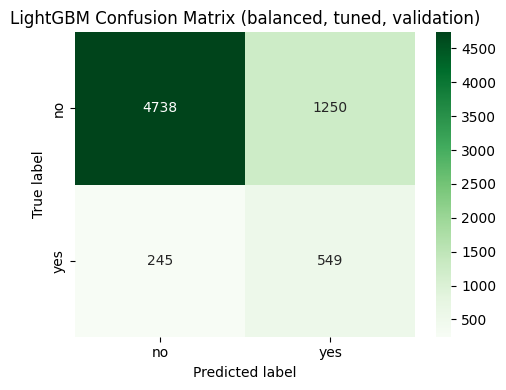

In [95]:
probs = globals().get("probs_val_LGBM_BAL_TUNED")
thresh = globals().get("THRESH_LGBM_BAL_TUNED")
y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("LightGBM Confusion Matrix (balanced, tuned, validation)")
plt.tight_layout()
plt.show()


##### LightGBM (Balanced, Tuned)  -Final Validation Metrics
- After completing hyperparameter tuning and locking the chosen threshold, we report the final validation metrics for the balanced LightGBM model.


In [96]:
acc = accuracy_score(y_val_b, y_pred)
rec = recall_score(y_val_b, y_pred, zero_division=0)
prec = precision_score(y_val_b, y_pred, zero_division=0)
f1 = f1_score(y_val_b, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1 Score:  {f1:.3f}")     
 

Accuracy:  0.780
Recall:    0.691
Precision: 0.305
F1 Score:  0.423


##### LightGBM ROC Curve (Balanced, Tuned)

- The ROC curve shows the performance of the tuned, balanced LightGBM model on the validation set across different thresholds. It plots the true positive rate (sensitivity) against the false positive rate (1 − specificity).

- The AUC (Area Under the Curve) summarizes this in a single number, higher AUC generally means the model separates the positive and negative classes better.
- This plot helps you see how well the model can distinguish the two classes over all possible thresholds, and AUC is often used with imbalanced data because it is not strongly affected by the class proportions.        

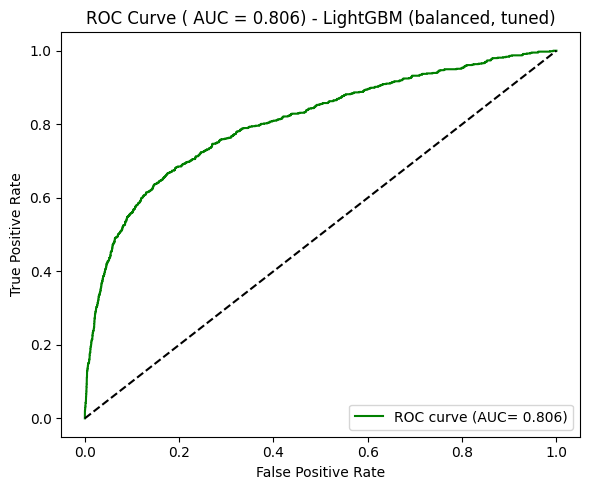

In [97]:
probs = globals().get("probs_val_LGBM_BAL_TUNED")

y_true = np.array(Y_val, dtype=int)

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_true, probs)
auc = roc_auc_score(y_true, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC= {auc:.3f})', color='GREEN')
plt.plot([0, 1], [0, 1], 'k--', )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve ( AUC = {auc:.3f}) - LightGBM (balanced, tuned)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

##### CatBoost (Unweighted) Hyperparameter Tuning
- The CatBoost (unweighted) model will be further optimized through hyperparameter tuning.


In [98]:
# Define hyperparameter grid for tuning (remove num_leaves, use depth)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1]
}

model_catb_unw = CatBoostClassifier(
    random_state=42,
    verbose=0
)
grid_search = GridSearchCV(
    model_catb_unw,
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_final, Y_train)
print(f"Best hyperparameters: {grid_search.best_params_}")

best_cat= grid_search.best_estimator_
best_recall = grid_search.best_score_
probs_val = best_cat.predict_proba(X_val_final)[:, 1]
print(f"Best cross-validated recall: {best_recall:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
Best cross-validated recall: 0.2453


##### CatBoost (unweighted, tuned) - Fit + cache VAL probabilities

In [99]:
Model_Name = "CatBoost (unweighted, tuned)"
Model_Tag = "CATB_UNW_TUNED"

# Construct CatBoost model with tuned hyperparameters
model_catb_unw_tuned = CatBoostClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

# Safety Checks
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."
# Fit the model
model_catb_unw_tuned.fit(X_train_final, Y_train)

# cache validation probabilities
probs_val = model_catb_unw_tuned.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val
globals()[f"model_{Model_Tag}"] = model_catb_unw_tuned  
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}.")

[OK] 'CatBoost (unweighted, tuned)' fitted — cached as probs_val_CATB_UNW_TUNED.


##### CatBoost (Unweighted, Tuned) - Threshold Sweep, Selection, and Lock

- After hyperparameter tuning, run a second threshold sweep using the tuned unweighted CatBoost validation probabilities.
- Select the best threshold based on the recall–precision trade-off.
- Fix the chosen threshold for the final evaluation.
- Document the final threshold, metrics, and key note

In [100]:
Model_Tag = "CATB_UNW_TUNED"
probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)



threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])


metrics_df = pd.DataFrame(
    metrics,
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df) 

# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]   
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")
    

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.770717,0.706549,0.297929,0.419126,0.277647
1,0.11,0.795636,0.681360,0.323178,0.438412,0.246830
2,0.12,0.821144,0.659950,0.357192,0.463512,0.216308
3,0.13,0.836774,0.639798,0.382242,0.478568,0.195960
4,0.14,0.847390,0.624685,0.402271,0.489393,0.181805
5,0.15,0.856532,0.613350,0.422376,0.500257,0.170009
6,0.16,0.861840,0.594458,0.434223,0.501861,0.160277
7,0.17,0.865821,0.579345,0.444015,0.502732,0.152757
8,0.18,0.870392,0.569270,0.457027,0.507011,0.145827
9,0.19,0.874226,0.555416,0.468650,0.508357,0.138750



[LOCKED] THRESH_CATB_UNW_TUNED = 0.11


##### CatBoost (Unweighted, Tuned) — Confusion Matrix (Validation)

- Confusion matrix for the tuned unweighted CatBoost model on the validation set.

- Shows TP/FP/TN/FN to explain performance beyond accuracy.

- Focus on recall for the minority “yes” class and check for high false negatives (FN).

- Document key results and takeaways.

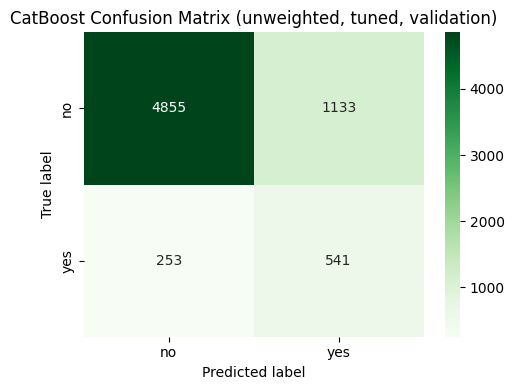

In [101]:
probs = globals ()[f"probs_val_{Model_Tag}"]
thresh = globals() [f"THRESH_{Model_Tag.upper()}"] 

y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)      
labels = ['no', 'yes']

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("CatBoost Confusion Matrix (unweighted, tuned, validation)")
plt.tight_layout()
plt.show()

##### CatBoost (Unweighted, Tuned) — Final Validation Metrics
- After completing hyperparameter tuning and locking the selected threshold, the final validation metrics for the tuned unweighted CatBoost model are summarized here.

In [102]:
acc = accuracy_score(y_val_b, y_pred)
rec = recall_score(y_val_b, y_pred, zero_division=0)
prec = precision_score(y_val_b, y_pred, zero_division=0)
f1 = f1_score(y_val_b, y_pred, zero_division=0)

# Print final metrics
print(f"Accuracy:  {acc:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1 Score:  {f1:.3f}")

Accuracy:  0.796
Recall:    0.681
Precision: 0.323
F1 Score:  0.438


##### CatBoost (Unweighted, Tuned) — ROC Curve & AUC (Validation)
- The ROC curve shows the tuned unweighted CatBoost model’s performance on the validation set across different threshold values. It plots the true positive rate (sensitivity) against the false positive rate (1 − specificity).

- AUC (Area Under the Curve) summarizes this curve in a single value—higher AUC generally means the model separates the positive and negative classes better.
- This plot helps visualize how well the model can distinguish between classes over all thresholds, and AUC is commonly used with imbalanced data because it is not strongly affected by class proportions.

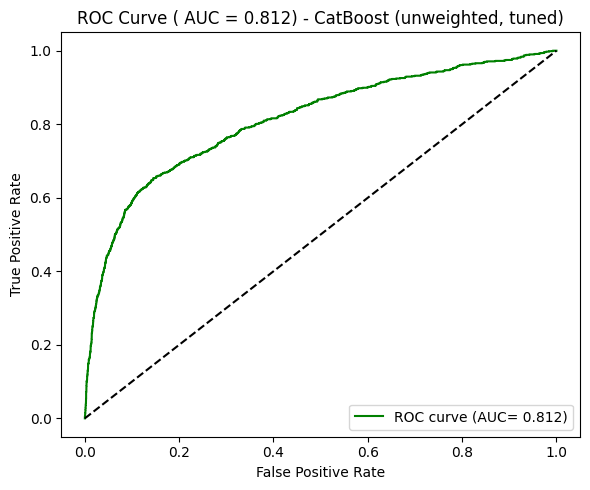

In [103]:
probs = globals().get("probs_val_CATB_UNW_TUNED")
y_true = np.array(Y_val, dtype=int)

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_true, probs)
auc = roc_auc_score(y_true, probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC= {auc:.3f})', color='GREEN')
plt.plot([0, 1], [0, 1], 'k--', )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve ( AUC = {auc:.3f}) - CatBoost (unweighted, tuned)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()      

##### LightGBM (Unweighted, Tuned) Hyperparameter Tuning
- The unweighted LightGBM model will be further optimized through hyperparameter tuning.

In [104]:
# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7,-1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63]

}

model_lgbm_unw = LGBMClassifier(  random_state=42,    scale_pos_weight=1,    verbose=-1)

grid_search = GridSearchCV(
    model_lgbm_unw,
    param_grid,
    scoring='recall',   
    cv=5,
    n_jobs=-1,
    verbose=2)


grid_search.fit(X_train_final, Y_train)
print(f"Best hyperparameters: {grid_search.best_params_}")  
best_recall = grid_search.best_score_
print(f"Best cross-validated recall: {best_recall:.4f}")
best_lgbm = grid_search.best_estimator_

probs_val = best_lgbm.predict_proba(X_val_final)[:, 1]

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 63}
Best cross-validated recall: 0.2561


##### LightGBM (Unweighted, Tuned) Fit + cache Validation probabilities


In [105]:

Model_Name = "LightGBM (unweighted, tuned)"
Model_Tag = "LGBM_UNW_TUNED"    

# Create the LightGBM model with tuned hyperparameters
best_lghbm_unw = LGBMClassifier(
    n_estimators=200,
    max_depth=-1,
    learning_rate= 0.1,
    num_leaves=63,
    random_state=42,
    scale_pos_weight=1,
    verbose=-1
)

# Safety check
assert 'X_train_final' in globals() and 'X_val_final' in globals(), "Preprocessing/split missing."
assert X_train_final.shape[0] == len(Y_train) and X_val_final.shape[0] == len(Y_val), "Shape mismatch."


# Fit model
best_lghbm_unw.fit(X_train_final, Y_train)

probs_val = best_lghbm_unw.predict_proba(X_val_final)[:, 1]
globals()[f"probs_val_{Model_Tag}"] = probs_val     
globals()[f"model_{Model_Tag}"] = best_lghbm_unw
print(f"[OK] '{Model_Name}' fitted — cached as probs_val_{Model_Tag}")

[OK] 'LightGBM (unweighted, tuned)' fitted — cached as probs_val_LGBM_UNW_TUNED


##### LightGBM (Unweighted, Tuned) - Threshold Sweep, Selection, and Lock
- After hyperparameter tuning, run a second threshold sweep on the tuned unweighted LightGBM model using the cached validation probabilities.

In [106]:
Model_Tag = "LGBM_UNW_TUNED"

probs_val = globals()[f"probs_val_{Model_Tag}"]
y_val_b = np.array(Y_val, dtype=int)

threshold = np.round(np.arange(0.10, 0.51, 0.01), 2)
precision_floor = 0.30

metrics = []
for thresh in threshold:
    y_pred = (probs_val >= thresh).astype(int)
    metrics.append([
        thresh,
        accuracy_score(y_val_b, y_pred),
        recall_score(y_val_b, y_pred, zero_division=0),
        precision_score(y_val_b, y_pred, zero_division=0),
        f1_score(y_val_b, y_pred, zero_division=0),
        float(y_pred.mean())
    ])

metrics_df = pd.DataFrame(
    metrics,    
    columns=["Threshold", "Accuracy", "Recall", "Precision", "F1_Score", "Predicted_positive_rate"]
)
display(metrics_df)

# Lock (“choose”) best threshold:
# 1) highest Recall among rows with Precision >= precision_floor
best_f1 = metrics_df.loc[metrics_df["F1_Score"].idxmax()]
guard = metrics_df[metrics_df["Precision"] >= precision_floor]
recall_first = guard.loc[guard["Recall"].idxmax()] if not guard.empty else None
if recall_first is not None:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(recall_first["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(recall_first['Threshold']):.2f}")
else:
    globals()[f"THRESH_{Model_Tag.upper()}"] = float(best_f1["Threshold"])
    print(f"\n[LOCKED] THRESH_{Model_Tag.upper()} = {float(best_f1['Threshold']):.2f}")
    

,Threshold,Accuracy,Recall,Precision,F1_Score,Predicted_positive_rate
0,0.10,0.772044,0.696474,0.297632,0.417044,0.273960
1,0.11,0.789590,0.668766,0.313274,0.426677,0.249926
2,0.12,0.805809,0.647355,0.331399,0.438380,0.228694
3,0.13,0.819670,0.629723,0.349895,0.449843,0.210705
4,0.14,0.828517,0.614610,0.362825,0.456288,0.198319
5,0.15,0.837806,0.593199,0.377404,0.461312,0.184017
6,0.16,0.843999,0.578086,0.388325,0.464575,0.174285
7,0.17,0.850634,0.565491,0.401970,0.469911,0.164701
8,0.18,0.855647,0.545340,0.411989,0.469377,0.154969
9,0.19,0.859776,0.527708,0.421106,0.468418,0.146712



[LOCKED] THRESH_LGBM_UNW_TUNED = 0.11


##### Results : LightGBM (Unweighted, Tuned)
- **Best Threshhold : 0.11**
- **Recall : 0.669** 
  - The model catch about 66.9% of the real 'yes' cases(so we miss ~33.1%).

- **Precision = 0.313**
  - When the model says “yes,” it is correct about 31.3% of the time.

- **F1 Score : 0.427**
  -  This reflects the overall balance between recall and precision at this cutoff.


- **Accuracy = 0.790**
 - About 79.0% of all predictions are correct (useful for context, but not the main goal here).

- **Predicted Positive Rate = 0.250**
  - The model predicts “yes” for about 25.0% of validation cases at this threshold.

##### LightGBM (Unweighted, Tuned) - Confusion Matrix (Validation)

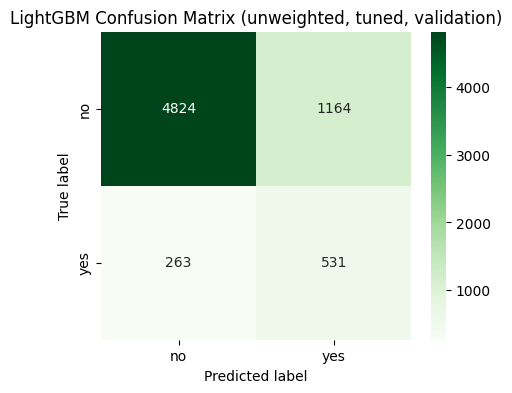

In [107]:
probs = globals().get("probs_val_LGBM_UNW_TUNED")
thresh = globals().get("THRESH_LGBM_UNW_TUNED")

y_val_b = np.array(Y_val, dtype=int)
y_pred = (probs >= thresh).astype(int)
# Confusion matrix
cm = confusion_matrix(y_val_b, y_pred)
labels = ['no', 'yes']
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")       
plt.ylabel("True label")
plt.title("LightGBM Confusion Matrix (unweighted, tuned, validation)")
plt.show()  


##### LightGBM (Unweighted, Tuned) — Final Validation Metrics
- After completing hyperparameter tuning and locking the selected threshold, the final validation metrics for the tuned unweighted LightGBM model are reported here.


In [108]:
acc = accuracy_score(y_val_b, y_pred)
rec = recall_score(y_val_b, y_pred, zero_division=0)
prec = precision_score(y_val_b, y_pred, zero_division=0)
f1 = f1_score(y_val_b, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1 Score:  {f1:.3f}")

Accuracy:  0.790
Recall:    0.669
Precision: 0.313
F1 Score:  0.427


##### LightGBM ROC Curve (Unweighted, Tuned)

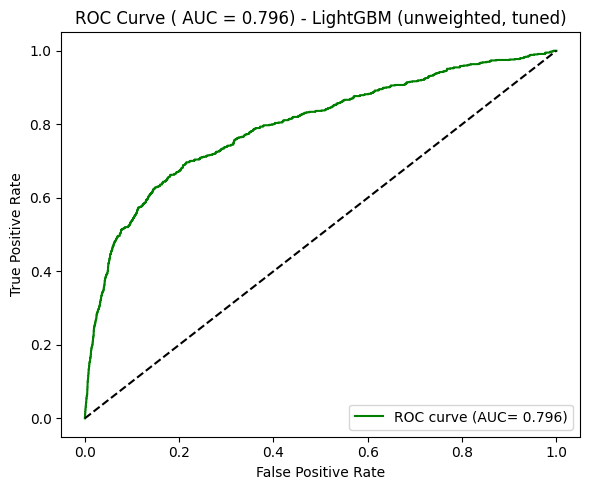

In [109]:
probs= globals().get("probs_val_LGBM_UNW_TUNED")
y_true = np.array(Y_val, dtype=int)

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_true, probs)
auc = roc_auc_score(y_true, probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC= {auc
:.3f})', color='GREEN')
plt.plot([0, 1], [0, 1], 'k--', )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve ( AUC = {auc:.3f}) - LightGBM (unweighted, tuned)')
plt.legend(loc='lower right')   
plt.tight_layout()
plt.show()


---

##### Final Comparison Table: Top 3 Models Before vs. After Hyperparameter Tuning (Validation)
- This table compares key validation metrics: recall, precision, F1, accuracy, predicted positive rate, and the selected threshold for the top three models before and after hyperparameter tuning.

-  It highlights performance changes from tuning and helps determine the strongest model to carry forward for final evaluation.


In [110]:
final_models = [
    (
        "CatBoost (Unweighted)", "probs_val_CATB_UNW", "THRESH_CATB_UNW",
        "CatBoost (unweighted, tuned)", "probs_val_CATB_UNW_TUNED", "THRESH_CATB_UNW_TUNED"
    ),
    (
        "LightGBM (Unweighted)", "probs_val_LGBM_UNW", "THRESH_LGBM_UNW",
        "LightGBM (unweighted, tuned)", "probs_val_LGBM_UNW_TUNED", "THRESH_LGBM_UNW_TUNED"
    ),
    (
        "LightGBM (Balanced)", "probs_val_LGBM_BAL", "THRESH_LGBM_BAL",
        "LightGBM (balanced, tuned)", "probs_val_LGBM_BAL_TUNED", "THRESH_LGBM_BAL_TUNED"
    )
]

y_val_b = np.array(Y_val, dtype=int)
final_results = []

for untuned, untuned_probs_var, untuned_thresh_var, tuned, tuned_probs_var, tuned_thresh_var in final_models:
    # Untuned model evaluation
    untuned_probs = globals().get(untuned_probs_var)
    untuned_thresh = globals().get(untuned_thresh_var)

    if untuned_probs is not None and untuned_thresh is not None:

        y_pred_untuned = (untuned_probs >= untuned_thresh).astype(int)

        final_results.append({
            "Model": untuned,
            "Threshold": float(untuned_thresh),
            "Recall": recall_score(y_val_b, y_pred_untuned, zero_division=0),
            "Precision": precision_score(y_val_b, y_pred_untuned, zero_division=0),
            "F1": f1_score(y_val_b, y_pred_untuned, zero_division=0),
            "Accuracy": accuracy_score(y_val_b, y_pred_untuned),
            "Predicted Positive Rate": float(y_pred_untuned.mean())
        })
    else:
        print(f"Warning: Data for untuned model '{untuned}' not found.")
    # Tuned model evaluation
    tuned_probs = globals().get(tuned_probs_var)
    tuned_thresh = globals().get(tuned_thresh_var)

    if tuned_probs is not None and tuned_thresh is not None:
        y_pred_tuned = (tuned_probs >= tuned_thresh).astype(int)

        final_results.append({
            "Model": tuned,
            "Threshold": float(tuned_thresh),
            "Recall": recall_score(y_val_b, y_pred_tuned, zero_division=0),
            "Precision": precision_score(y_val_b, y_pred_tuned, zero_division=0),
            "F1": f1_score(y_val_b, y_pred_tuned, zero_division=0),
            "Accuracy": accuracy_score(y_val_b, y_pred_tuned),
            "Predicted Positive Rate": float(y_pred_tuned.mean())
        })
    else:
        print(f"Warning: Data for tuned model '{tuned}' not found.")

    # Create DataFrame of final results
results_df = pd.DataFrame(final_results).set_index("Model").round(3)

# soert by Recall descending
results_df = results_df.sort_values(by="Recall", ascending=False)

top_3_models = results_df.head(3)
display(top_3_models)

best_model_name = top_3_models.index[0]

best_threshhold = top_3_models.loc[best_model_name,['Threshold']]
print(F" Top model chosen for deployment: {best_model_name} with  {best_threshhold}")
                                   

,Threshold,Recall,Precision,F1,Accuracy,Predicted Positive Rate
Model,,,,,,
LightGBM (Balanced),0.45,0.704,0.304,0.425,0.777,0.271
"LightGBM (balanced, tuned)",0.47,0.691,0.305,0.423,0.780,0.265
"CatBoost (unweighted, tuned)",0.11,0.681,0.323,0.438,0.796,0.247


 Top model chosen for deployment: LightGBM (Balanced) with  Threshold    0.45
Name: LightGBM (Balanced), dtype: float64


In [134]:

# Keep a compact top 3 view in output

top_3_models = results_df.head(3)
display(top_3_models)


#winner name + threshold for deployment
best_model_name = top_3_models.index[0]
best_threshhold = top_3_models.loc[best_model_name, ['Threshold']]
print(f" Winner: {best_model_name} with  {best_threshhold}")

,Threshold,Recall,Precision,F1,Accuracy,Predicted Positive Rate
Model,,,,,,
LightGBM (Balanced),0.45,0.704,0.304,0.425,0.777,0.271
"LightGBM (balanced, tuned)",0.47,0.691,0.305,0.423,0.780,0.265
"CatBoost (unweighted, tuned)",0.11,0.681,0.323,0.438,0.796,0.247


 Winner: LightGBM (Balanced) with  Threshold    0.45
Name: LightGBM (Balanced), dtype: float64


---

#####  Load the Fitted Model for the winner

In [118]:
import re 

def resolve_model_tag(display_name, final_models):
    """
    1) Use final_models to find the corresponding probs var for this display_name
    2) Derive a tag (strip 'probs_val_') and look for globals()[f'model_{tag}']
    3) Fall back to common names if needed
    """
    # Build a mapping from model name → prob-variable name
    name_to_probs_var = {}
    for untuned, untuned_probs_var, _, tuned, tuned_probs_var, _ in final_models:
        name_to_probs_var[untuned] = untuned_probs_var
        name_to_probs_var[tuned] = tuned_probs_var

    probs_var = name_to_probs_var.get(display_name)

    # Try the "standard" model name: model_<tag>
    candidate_tags = []
    if probs_var:
        tag = re.sub(r'^probs_val_', '', probs_var)
        candidate_tags.append(tag.upper())

    # Add fallback variable names by model family
    lname = display_name.lower()
    if 'catboost' in lname:
        candidate_tags += ["CATB_UNW_TUNED", "CATB_BAL", "CATB_UNW"]
    if 'lightgbm' in lname:
        candidate_tags += ["LGBM_UNW_TUNED", "LGBM_BAL_TUNED", "LGBM_BAL", "LGBM_UNW"]
    if 'xgboost' in lname or 'XGB' in lname:
        candidate_tags += ["XGB_BAL", "XGB_UNW"]
    if 'random forest' in lname or 'RF' in lname:
        candidate_tags += ["RF_BAL", "RF_UNW"]

    # Search for model in globals
    for tag in candidate_tags:
        model = globals().get(f"model_{tag}")
        if model is not None:
            return tag, model

    raise RuntimeError(f"Could not resolve a fitted model object for: {display_name}")


# Use it for the winner
model_var_name, model_obj = resolve_model_tag(best_model_name, final_models)
print(f"[Resolved] Using model object from: model_{model_var_name}")


[Resolved] Using model object from: model_LGBM_BAL


##### Recreate Training “Handles” for Final Test Evaluation

In [140]:
# This is needed for final evaluation on the TEST set

def train_handles():
    """
    Ensures X_train_raw, y_train, and train_idx exist.
    Uses your standard 70/15/15 stratified split and excludes 'duration' from features.
    """
    if all(k in globals() for k in ["X_train_raw", "y_train", "train_idx"]):
        print("[OK] TRAIN handles already present: X_train_raw, y_train, train_idx")
        return

    assert "df" in globals(), ("DataFrame 'df' not found in globals.")

    df_copy = df.copy()

    y_all = df_copy["y"]
    if y_all.dtype.kind in {'i', 'u', 'b'}:
        y_all = y_all.astype(int)
    else:
        y_all = (y_all.astype(str).str.lower().str.strip() == "yes").astype(int)

    X_all = df_copy.drop(columns=['y', 'duration'], errors='ignore')

    X_train_raw_, X_temp, y_train_, y_temp = train_test_split(
        X_all, y_all, test_size=0.30, stratify=y_all, random_state=42
    )

    X_val_raw_, X_test_raw_, y_val_, y_test_ = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
    )

    mask = df_copy.index.isin(X_train_raw_.index)

    globals()["X_train_raw"] = X_train_raw_
    globals()["y_train"] = y_train_
    globals()["train_idx"] = mask
    globals()["X_val_raw"] = X_val_raw_
    globals()["y_val"] = y_val_
    globals()["X_test_raw"] = X_test_raw_
    globals()["y_test"] = y_test_

    print(
        f"[OK] TRAIN/VAL/TEST rebuilt | "
        f"TRAIN: {X_train_raw_.shape} | VAL: {X_val_raw_.shape} | TEST: {X_test_raw_.shape} "
        f"| Pos rate (VAL): {y_val_.mean():.3f}"
    )

train_handles()

[OK] TRAIN handles already present: X_train_raw, y_train, train_idx


##### Final model pipeline with preprocessing steps 

In [144]:
# Cilumns ( exclude 'duration'
categorial_cols = ["job","marital","education","default","housing","loan","contact","month","poutcome"]
numerical_cols = ["age","balance","day","campaign","pdays","previous"]

preprocessor = ColumnTransformer(transformers=[("numerical",StandardScaler(), numerical_cols),
    ("categorical",OneHotEncoder(handle_unknown="ignore",sparse_output=False), categorial_cols),]) 

#
final_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("clf", model_obj)]) # 

# Fthe pipeline on training data

if 'X_train_raw' in globals() and 'y_train' in globals():
    X_train = X_train_raw.drop(columns=['duration'], errors='ignore') # type: ignore
    final_pipeline.fit(X_train, globals()['y_train'])
    
elif 'df' in globals() and 'train_idx' in globals():
    X_train = df.loc[train_idx].drop(columns=['y','duration'], errors='ignore') # type: ignore
    y_train = (df.loc[train_idx,'y'].astype(str).str.lower()=="yes").astype(int) # type: ignore
    final_pipeline.fit(X_train, y_train)
else:
    raise RuntimeError("Need X_train_raw/y_train or df+train_idx to fit the final pipeline.")


#Save the trained pipeline to a file
joblib.dump(final_pipeline, "bankterm_pipeline.pkl")
with open("feature_schema.json","w") as f:
    json.dump({"categorical": categorial_cols, "numeric": numerical_cols, "target":"y"}, f, indent=2)

print(f"[Saved] bankterm_pipeline.pkl (from {best_model_name} via {model_var_name})")
print(f"[Action] In the Streamlit app, set LOCKED_THRESHOLD = {float(best_threshhold.iloc[0]):.2f}")

[Saved] bankterm_pipeline.pkl (from LightGBM (Balanced) via LGBM_BAL)
[Action] In the Streamlit app, set LOCKED_THRESHOLD = 0.45


Locked Threshold: 0.45
TEST Accuracy : 0.773
TEST Precision: 0.293
TEST Recall   : 0.67
TEST F1       : 0.408

Confusion Matrix [[TN FP],[FN TP]]:
[[4710 1279]
 [ 262  531]]
TN=4710, FP=1279, FN=262, TP=531


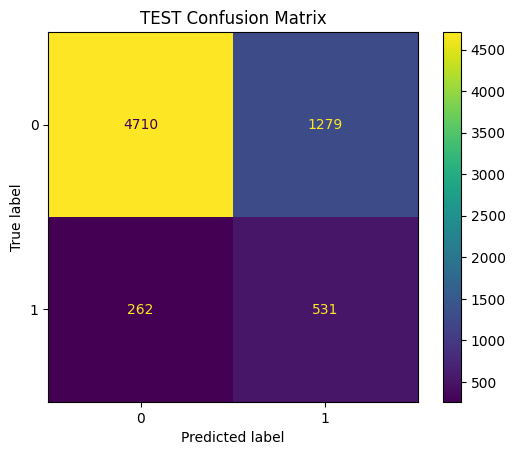

In [145]:
from sklearn.metrics import ConfusionMatrixDisplay

# === Final Check on TEST set 

# 1) Get locked threshold as a float
LOCKED_THRESHOLD = float(best_threshhold.iloc[0]) if 'best_threshhold' in globals() else float(best_threshold)

# 2) Ensure TEST handles are ready, then build X_test and y_test
if "X_test_raw" not in globals():
	if "train_handles" in globals():
		train_handles()
	else:
		raise RuntimeError("X_test_raw not found. Please run the data splitting cell before evaluating the test set.")

X_test = X_test_raw.drop(columns=['duration'], errors='ignore')
y_test_bin = np.array(y_test, dtype=int)

# 3) Predict probabilities on TEST
probs_test = final_pipeline.predict_proba(X_test)[:, 1]

# 4) Convert probs -> class predictions using the locked threshold
y_pred_test = (probs_test >= LOCKED_THRESHOLD).astype(int)

# 5) Metrics
print("Locked Threshold:", LOCKED_THRESHOLD)
print("TEST Accuracy :", round(accuracy_score(y_test_bin, y_pred_test), 3))
print("TEST Precision:", round(precision_score(y_test_bin, y_pred_test, zero_division=0), 3))
print("TEST Recall   :", round(recall_score(y_test_bin, y_pred_test, zero_division=0), 3))
print("TEST F1       :", round(f1_score(y_test_bin, y_pred_test, zero_division=0), 3))

# 6) Confusion matrix (TP/TN/FP/FN)
cm = confusion_matrix(y_test_bin, y_pred_test)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix [[TN FP],[FN TP]]:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# 7) Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("TEST Confusion Matrix")
plt.show()
